# Implementacion del codigo

# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold,KFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score,precision_score, classification_report, confusion_matrix,recall_score
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error, mean_squared_error, roc_curve, auc, RocCurveDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Cargado de datos

In [2]:
df=pd.read_csv("vehicles.csv")

In [3]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


# Funciones 

In [4]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [5]:
def calcular_vif(df, umbral=10.0):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    
    # Filtrar variables con VIF mayor al umbral
    altas = vif_data[vif_data["VIF"] > umbral]
    
    return vif_data.sort_values("VIF", ascending=False), altas

In [6]:
def analizar_modelo_lineal(best_model, X_train, X_test, y_test):
    # Predicciones en test
    y_pred = best_model.predict(X_test)

    # --- Gráfico Real vs Predicho ---
    plt.figure(figsize=(7,7))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2, label="Ideal (y=x)")
    plt.xlabel("Valores reales")
    plt.ylabel("Valores predichos")
    plt.title("Real vs Predicho")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    # --- Importancia de variables ---
    features = X_train.columns  
    coefs = best_model.coef_

    importances = pd.DataFrame({
        'feature': features,
        'coef': coefs,
        'importance_abs': np.abs(coefs)
    }).sort_values('importance_abs', ascending=False)

    print("Tabla de importancia de variables:")
    print(importances)

    # --- Gráfico de importancias ---
    plt.figure(figsize=(8, max(6, 28)))
    plt.barh(importances['feature'], importances['importance_abs'])
    plt.xlabel("Importancia (|coef|)")
    plt.title("Importancia de variables")
    plt.gca().invert_yaxis()
    plt.show()

    return importances

In [7]:
def analizar_modelo_clasificacion(best_model, X_train, X_test, y_test):
    # --- Curva ROC ---
    y_pred_prob = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    print("AUC:", roc_auc)

    # Gráfico ROC
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # línea base
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC - Mejor Modelo (GridSearch)')
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    # --- Importancia de variables ---
    coefs = best_model.coef_[0]  # clasificación binaria
    features = X_train.columns

    importances = pd.DataFrame({
        'feature': features,
        'coef': coefs,
        'importance_abs': np.abs(coefs)
    }).sort_values('importance_abs', ascending=False)

    print("\nTabla de importancia de variables:")
    print(importances)

    # Gráfico de importancias
    plt.figure(figsize=(8, max(6, len(features)*0.4)))
    plt.barh(importances['feature'], importances['importance_abs'])
    plt.xlabel("Importancia (|coef|)")
    plt.title("Importancia de variables - Modelo Logístico")
    plt.gca().invert_yaxis()
    plt.show()

    return importances

In [8]:
def Reporte_clasificacion(model, X_test, y_test):
    # Predicciones
    y_pred = model.predict(X_test)

    # Accuracy
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # Precision, Recall, F1
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1-score:", f1_score(y_test, y_pred, average="weighted"))

    # Matriz de confusión
    print("\nMatriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    # Reporte detallado por clase
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

# Analisis exploratorio de los datos

In [9]:
Summary(df,'df')

Hoja: df

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,426880,26,1655336,0



Encabezado:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [11]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


## Analisis de NA(EDA)

Revisamos los porcentajes de NA para luego realizar su tratamiento en el preprocesamiento de los datos

In [12]:
NA_porcentaje = df.isna().mean() * 100
print(NA_porcentaje.to_string())

id                0.000000
url               0.000000
region            0.000000
region_url        0.000000
price             0.000000
year              0.282281
manufacturer      4.133714
model             1.236179
condition        40.785232
cylinders        41.622470
fuel              0.705819
odometer          1.030735
title_status      1.930753
transmission      0.598763
VIN              37.725356
drive            30.586347
size             71.767476
type             21.752717
paint_color      30.501078
image_url         0.015930
description       0.016398
county          100.000000
state             0.000000
lat               1.534155
long              1.534155
posting_date      0.015930


Eliminamos la variable county debido a que tiene el 100% de NA

In [13]:
df=df.drop(columns="county")

## Graficas variables numericas y filtracion de outliers

Realizamos las graficas de las variables numericas 

In [14]:
num=['price','year','odometer']

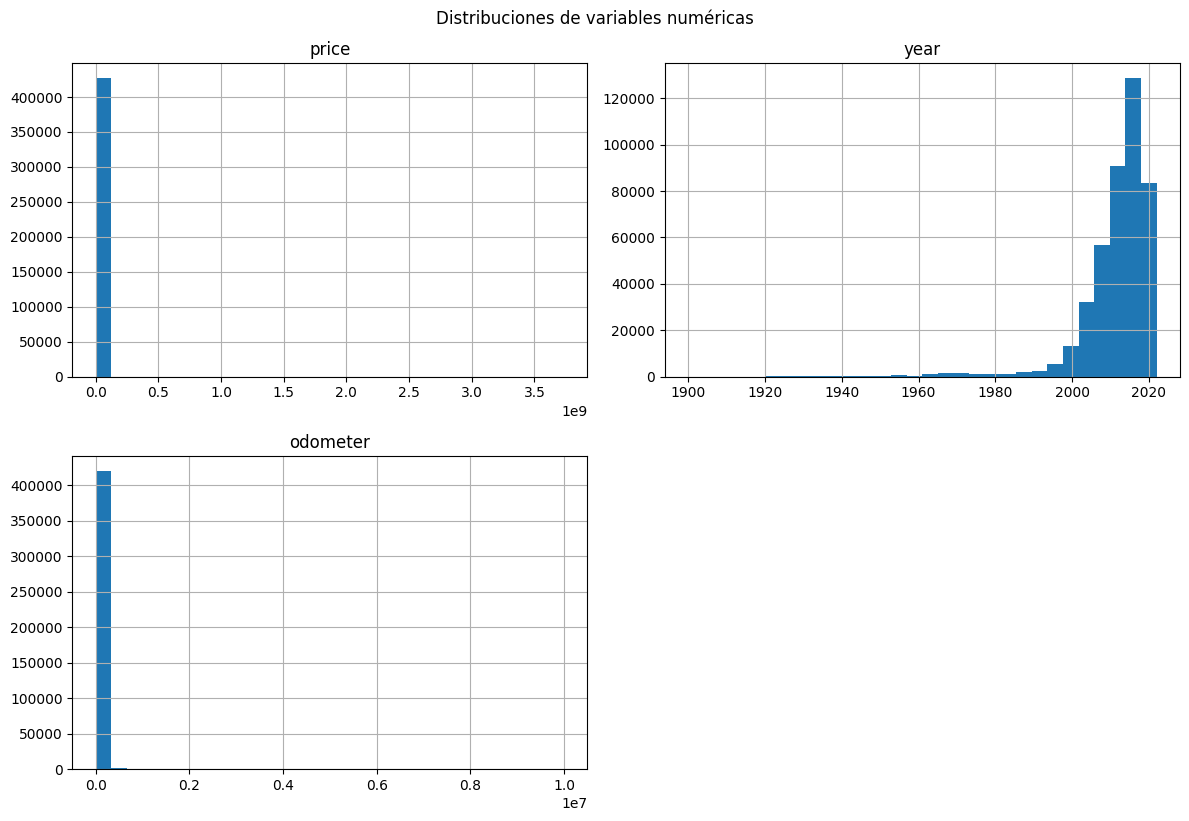

In [15]:
df[num].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.suptitle('Distribuciones de variables numéricas', y=1.02)
plt.show()

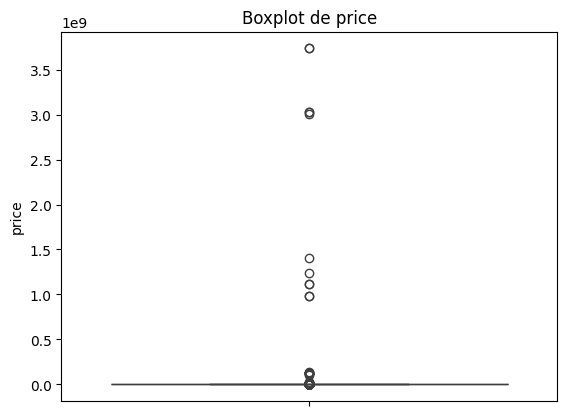

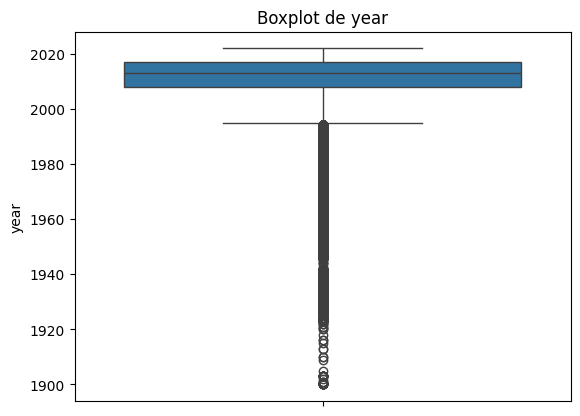

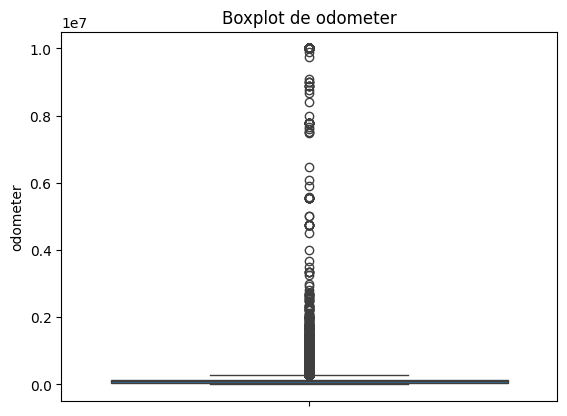

In [16]:
for numerica in num:
  sns.boxplot(data=df,y=numerica)
  plt.title(f'Boxplot de {numerica}')
  plt.show()

En el caso de la variable año sus datos atipicos si se pueden considerar como casos reales ya que los autos han existido desde el inicio del siglo 20

Revisaremos los valores atipicos de la variable price para tomar en cuenta en la parte de preprocesamiento

In [17]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_price = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print("Cantidad de outliers en price:", len(outliers_price))
print(f"Rango superior de atípicos: valores mayores a {upper_bound}")
print("\nEjemplo de outliers (los más bajos y más altos):")
print(outliers_price['price'].sort_values().head(5))   
print(outliers_price['price'].sort_values().tail(5))  

Cantidad de outliers en price: 8177
Rango superior de atípicos: valores mayores a 57364.375

Ejemplo de outliers (los más bajos y más altos):
414596    57400
336337    57400
303716    57400
364509    57427
30699     57460
Name: price, dtype: int64
37410     3009548743
91576     3024942282
257840    3024942282
356716    3736928711
318592    3736928711
Name: price, dtype: int64


Podemos observar que los outliers en la variable price son todos los valores mayores a 57 mil dolares, sin embargo este precio si es razonable a comparacion de los precios completamente irrealistas de algunas filas lo que lleva a que se distorsione el histograma

Como son valores realmente irrealistas se deben realizar la filtracion para la variable price ya que pueden distorcionar el escalado y la regresion mas adelante. Esto se realizara durante el preprocesamiento de datos

Revisamos los outliers de odometer

In [18]:
Q1_o = df['odometer'].quantile(0.25)
Q3_o = df['odometer'].quantile(0.75)
IQR_o = Q3_o - Q1_o
lower_bound_o = Q1_o - 1.5 * IQR_o
upper_bound_o = Q3_o + 1.5 * IQR_o
outliers_odometer = df[(df['odometer'] < lower_bound) | (df['odometer'] > upper_bound)]
print("Cantidad de outliers en odometer:", len(outliers_odometer))
print(f"Rango superior de atípicos: valores mayores a {upper_bound}")
print("\nEjemplo de outliers (los más bajos y más altos):")
print(outliers_odometer['odometer'].sort_values().head(5))   
print(outliers_price['odometer'].sort_values().tail(5)) 

Cantidad de outliers en odometer: 272897
Rango superior de atípicos: valores mayores a 57364.375

Ejemplo de outliers (los más bajos y más altos):
310172    57366.0
169986    57366.0
385399    57366.0
363379    57367.0
363258    57367.0
Name: odometer, dtype: float64
159678   NaN
159682   NaN
159685   NaN
159769   NaN
290548   NaN
Name: odometer, dtype: float64


Podemos observar que los valores atipicos de la variable odometer son valores mayores a 2277300 lo cual es un valor de odometer bastante alto y que los valores mas altos de outliers son atipicos y debemos imputarlos primero antes de poder tomar cualquier otra accion. Esto se realizara durante el preprocesamiento de datos

Realizamos un scatterplot de latitud y longitud 

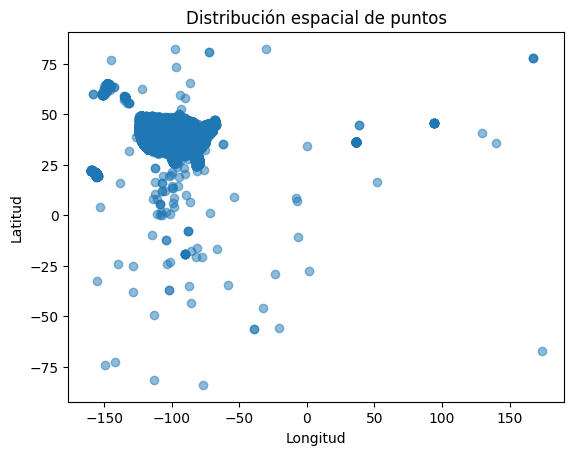

In [19]:
plt.scatter(df['long'], df['lat'], alpha=0.5)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribución espacial de puntos")
plt.show()

Codificamos la variable posting date como fecha 

In [20]:
df['posting_date']=pd.to_datetime(df['posting_date'],format='%d/%m/%Y',errors="coerce")

Realizamos los graficos de variables categoricas

In [21]:
categoricas=["region","manufacturer","condition","cylinders","fuel","title_status","transmission","drive","size","type","paint_color","state"]

region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64


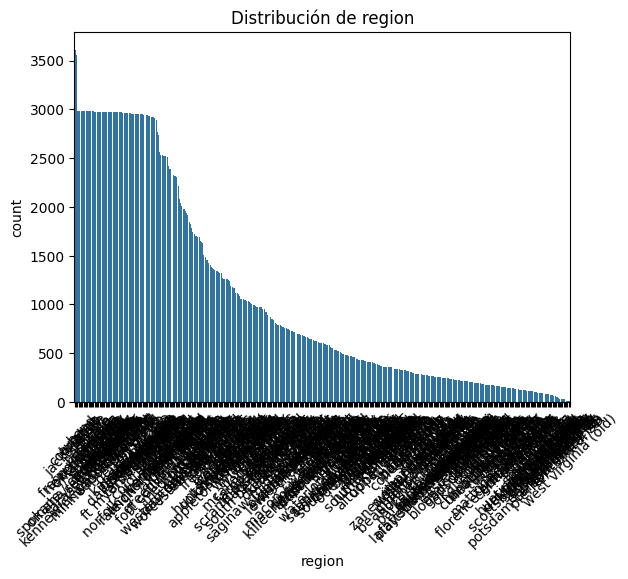

manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln             4220
volvo               3374
mitsubishi          3292
mini                2376
pontiac             2288
rover               2113
jaguar              1946
porsche             1384
mercury             1184
saturn              1090
alfa-romeo           897
tesla                868
fiat                 792
harley-davidson      153
ferrari               95
datsun                63
aston-martin

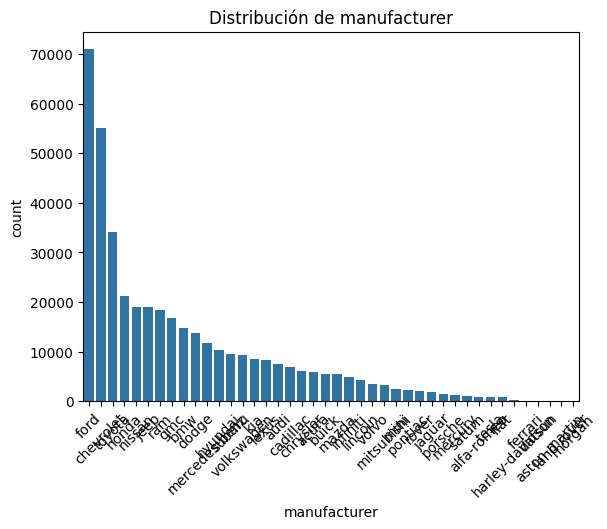

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64


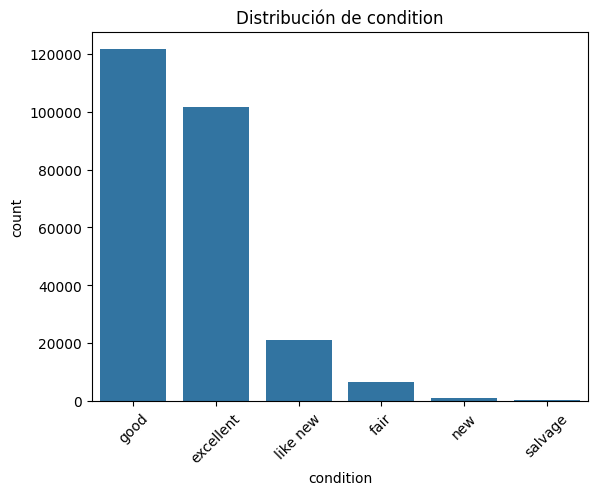

cylinders
6 cylinders     94169
4 cylinders     77642
8 cylinders     72062
5 cylinders      1712
10 cylinders     1455
other            1298
3 cylinders       655
12 cylinders      209
Name: count, dtype: int64


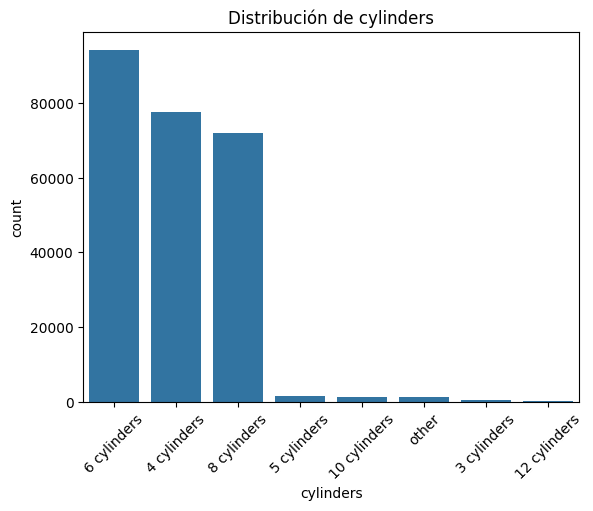

fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64


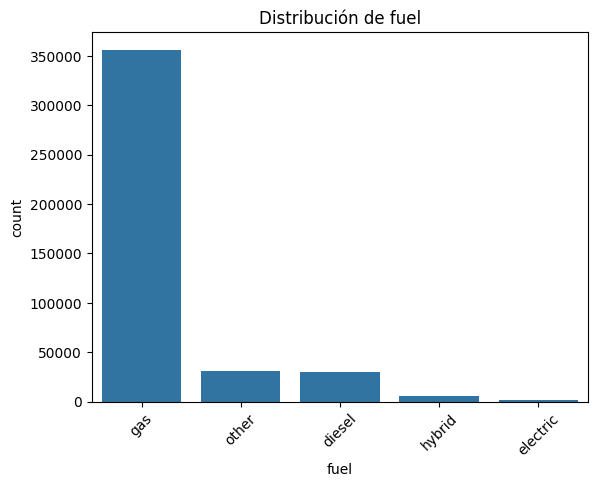

title_status
clean         405117
rebuilt         7219
salvage         3868
lien            1422
missing          814
parts only       198
Name: count, dtype: int64


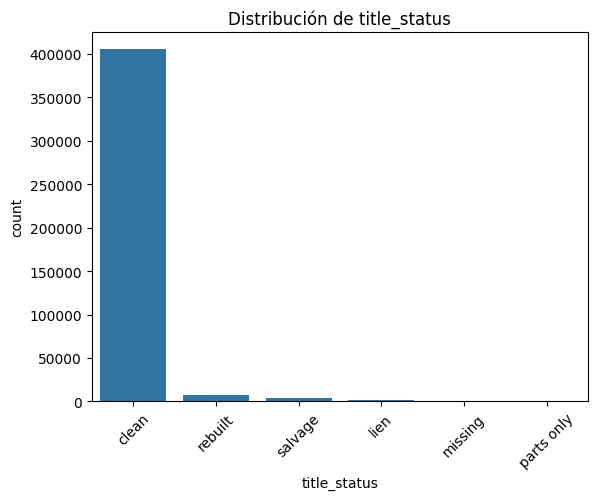

transmission
automatic    336524
other         62682
manual        25118
Name: count, dtype: int64


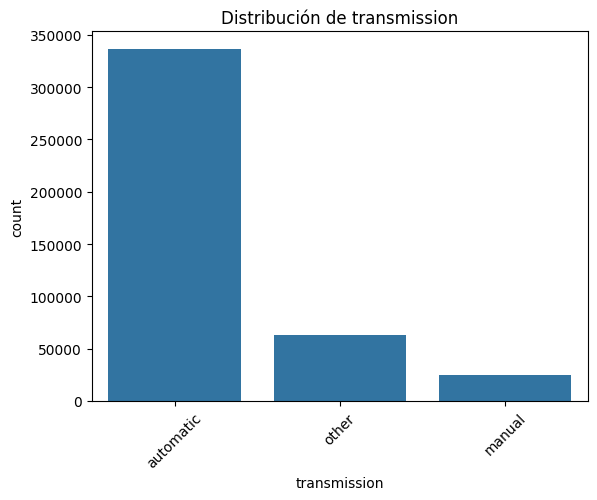

drive
4wd    131904
fwd    105517
rwd     58892
Name: count, dtype: int64


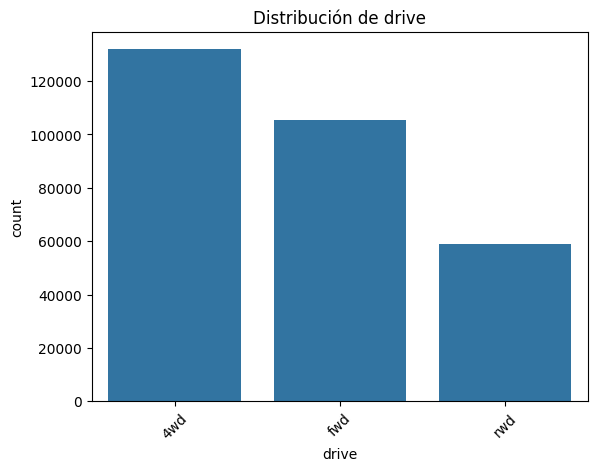

size
full-size      63465
mid-size       34476
compact        19384
sub-compact     3194
Name: count, dtype: int64


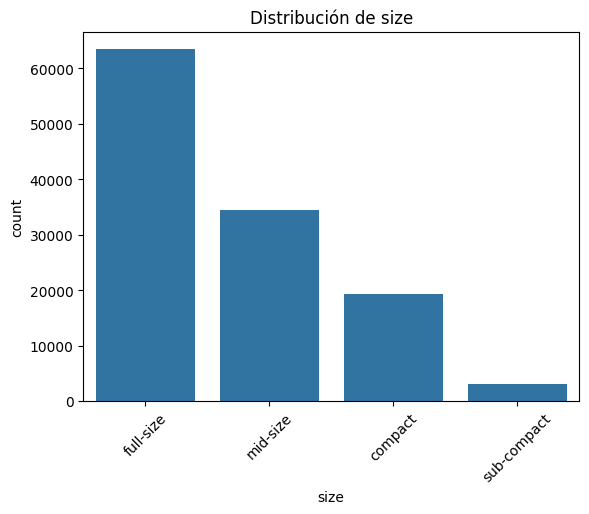

type
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          22110
coupe          19204
hatchback      16598
wagon          10751
van             8548
convertible     7731
mini-van        4825
offroad          609
bus              517
Name: count, dtype: int64


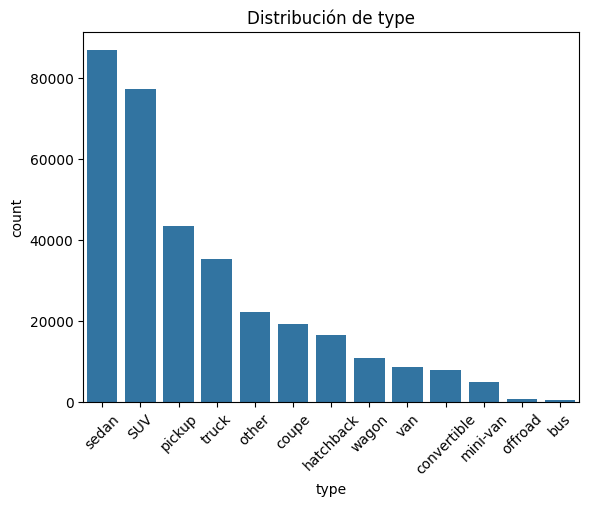

paint_color
white     79285
black     62861
silver    42970
blue      31223
red       30473
grey      24416
green      7343
custom     6700
brown      6593
yellow     2142
orange     1984
purple      687
Name: count, dtype: int64


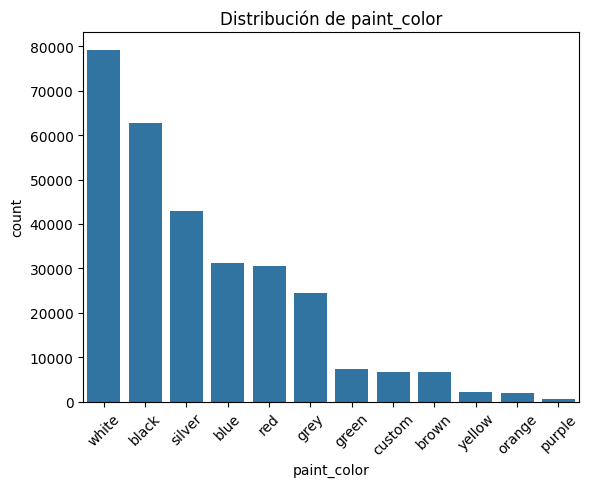

state
ca    50614
fl    28511
tx    22945
ny    19386
oh    17696
or    17104
mi    16900
nc    15277
wa    13861
pa    13753
wi    11398
co    11088
tn    11066
va    10732
il    10387
nj     9742
id     8961
az     8679
ia     8632
ma     8174
mn     7716
ga     7003
ok     6792
sc     6327
mt     6294
ks     6209
in     5704
ct     5188
al     4955
md     4778
nm     4425
mo     4293
ky     4149
ar     4038
ak     3474
la     3196
nv     3194
nh     2981
dc     2970
me     2966
hi     2964
vt     2513
ri     2320
sd     1302
ut     1150
wv     1052
ne     1036
ms     1016
de      949
wy      610
nd      410
Name: count, dtype: int64


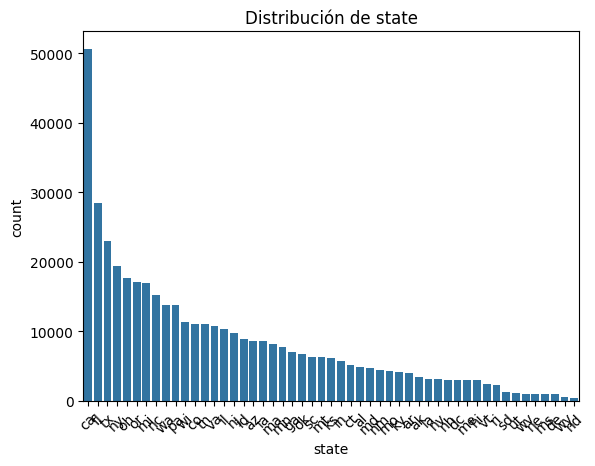

In [22]:
for col in categoricas:
    print(df[col].value_counts())
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.show()

En estos graficos se pueden observar las categorias de cada una de las variables y cuales son las que mas resaltan

Realizamos la matriz de correlacion de las variables numericas

In [23]:
matriz=df[num].corr()

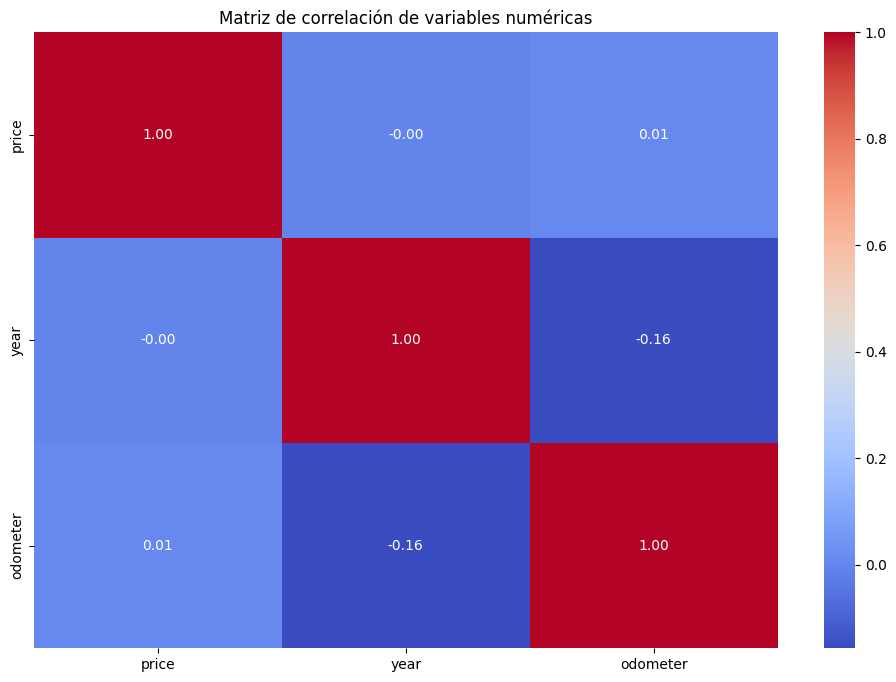

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(matriz, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

Se pueden observar que las correlaciones de las variables numericas es bastante baja. Lo cual es raro para las variables que deberian estar relacionadas. se realizara la matriz de correlacion despues del preprocesamiento.

# Preprocesamiento

En primer lugar se eliminan las variables que no son predictorias o importantes para el modelo

In [25]:
drop=["id","url","region_url","VIN","image_url","description","size","posting_date","model","region"]

In [26]:
df=df.drop(columns=drop)

## Tratamiento de outliers

Ahora se trataran los outliers de la variable price y la variable odometer. 
El tratamiento de price es clave para poder crear la variable HighDemand

Primero se revisan cuantos valores de 0 hay en las 2 variables

In [27]:
zeros_count = (df['odometer'] == 0).sum()
Zeros=(df['price'] == 0).sum()
print(f"Cantidad de registros con odometer = 0: {zeros_count}")
print(f"Cantidad de registros con price = 0: {Zeros}")

Cantidad de registros con odometer = 0: 1965
Cantidad de registros con price = 0: 32895


Volvemos los 0 de las variables como NA para imputarlos despues

In [28]:
df['odometer'] = df['odometer'].replace(0, np.nan)
df['price'] = df['price'].replace(0, np.nan)

print("NaN en odometer:", df['odometer'].isna().sum())
print("NaN en price:", df['price'].isna().sum())

NaN en odometer: 6365
NaN en price: 32895


Utilizamos el metodo de percentiles para filtrar los outliers de ambas variables 

In [29]:
p_low_price, p_high_price = df['price'].quantile([0.005, 0.995])
p_low_odo, p_high_odo     = df['odometer'].quantile([0.005, 0.995])

print("Umbral price:", p_low_price, "-", p_high_price)
print("Umbral odometer:", p_low_odo, "-", p_high_odo)

Umbral price: 3.0 - 78900.0
Umbral odometer: 1.0 - 351147.4899999976


Si bien los umbrales nos muestran los outliers reducidos, se utilizaran valores mas realistas de precio y odometer para eliminar valores irreales de datos usados

In [30]:
min_price_business = 500  
low_price = max(p_low_price, min_price_business)
high_price = p_high_price

In [31]:
min_odometer_business = 100
max_odometer_business = 500000
low_odo = max(p_low_odo, min_odometer_business)
high_odo = min(p_high_odo, max_odometer_business)

In [32]:
print(f"Umbral final price: {low_price} - {high_price}")
print(f"Umbral final odometer: {low_odo} - {high_odo}")

Umbral final price: 500 - 78900.0
Umbral final odometer: 100 - 351147.4899999976


Se filtran los outliers de las variables 

In [33]:
df_clean = df[
    (df['price'].isna() | ((df['price'] >= low_price) & (df['price'] <= high_price))) &
    (df['odometer'].isna() | ((df['odometer'] >= low_odo) & (df['odometer'] <= high_odo)))
]

Realizamos los histogramas y boxplots de las variables numericas nuevamente para revisar el cambio

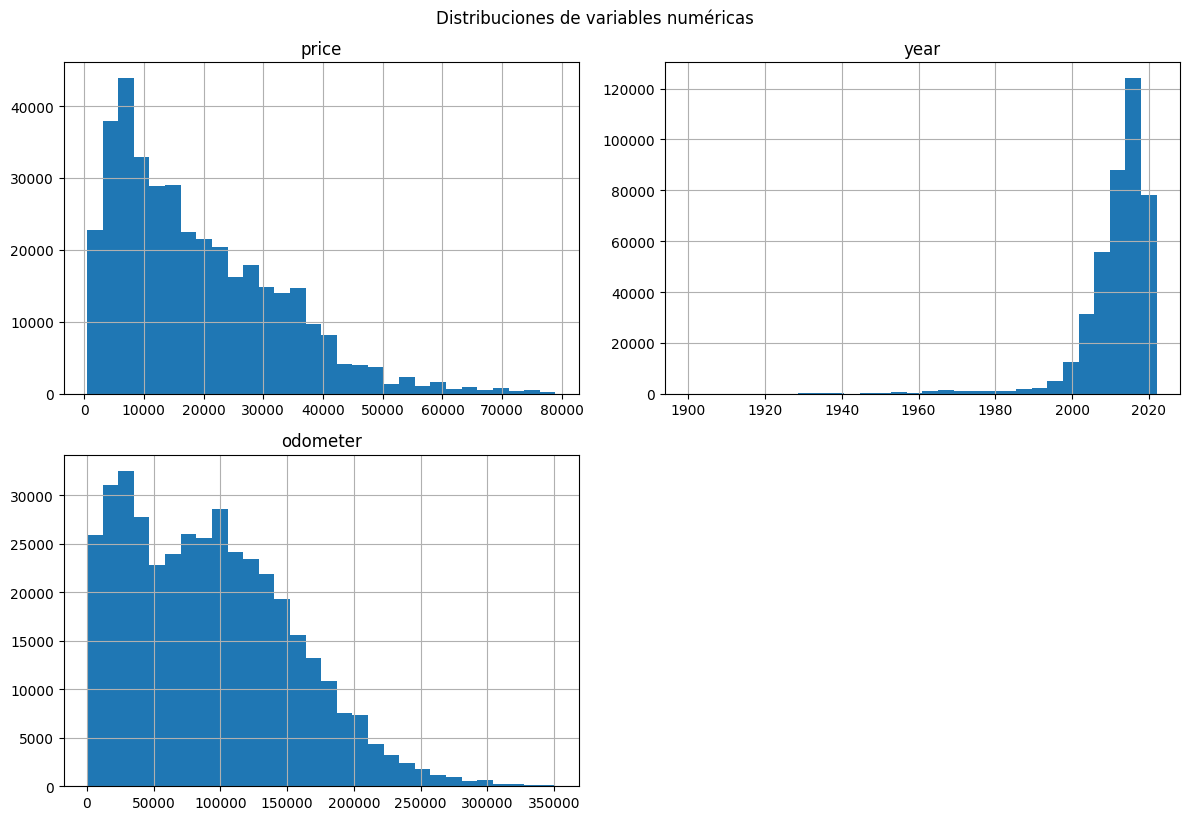

In [34]:
df_clean[num].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.suptitle('Distribuciones de variables numéricas', y=1.02)
plt.show()

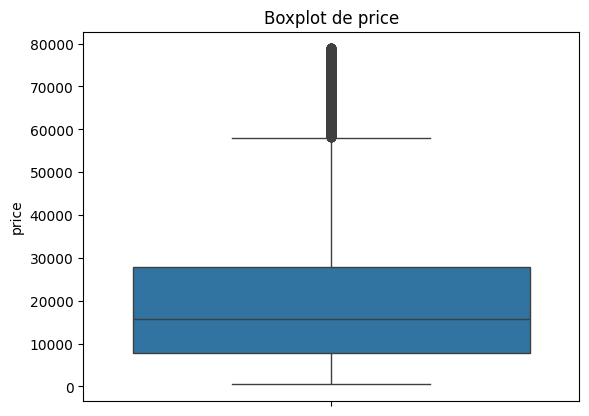

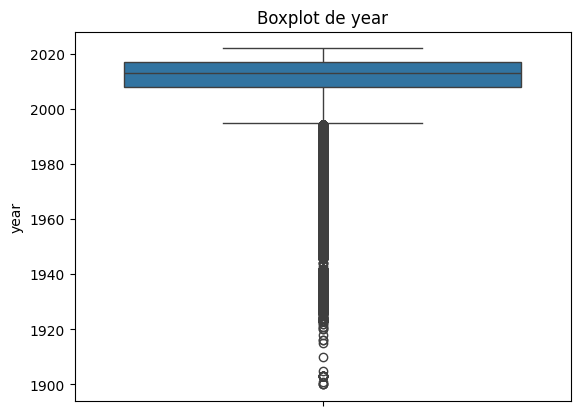

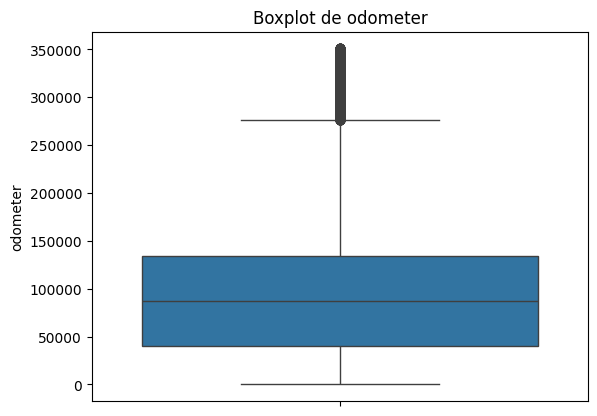

In [35]:
for numerica in num:
  sns.boxplot(data=df_clean,y=numerica)
  plt.title(f'Boxplot de {numerica}')
  plt.show()

Podemos observar que los valores son mas razonables en las variables numericas. y si son valores reales de precios de autos usados

Realizamos nuevamente la matriz de correlacion

In [36]:
matriz_out=df_clean[num].corr()

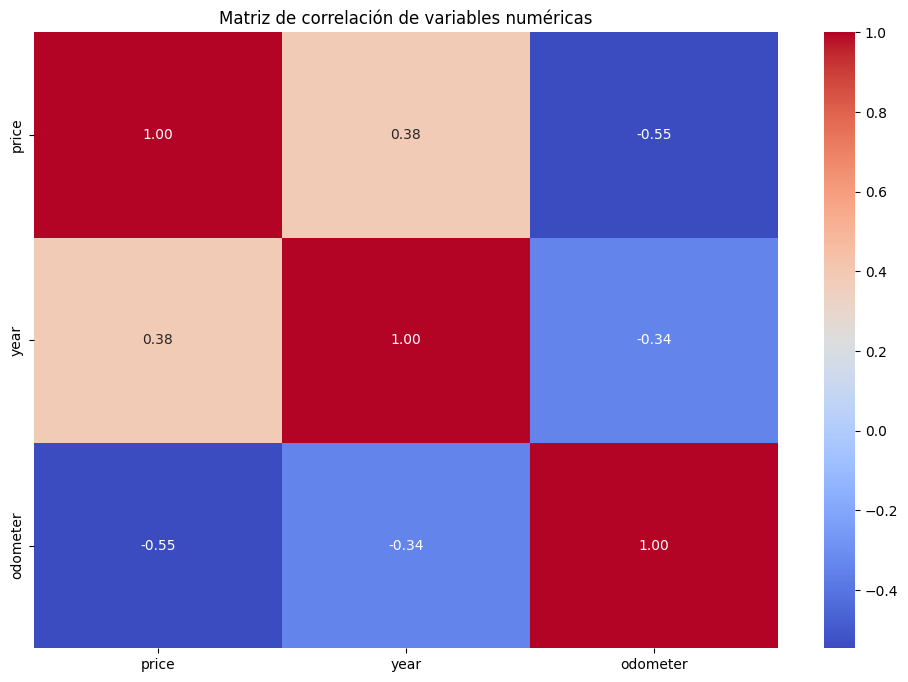

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(matriz_out, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables numéricas")
plt.show()

Podemos observar que gracias a la filtracion de los datos atipicos ahora existe una correlacion positiva entre el precio y el año 

Gracias a esto ya se puede realizar el split de los datos para crear la variable objetivo de clasificacion

## Split de los datos

### Clasificacion

Creamos la variable objetivo HighDemand

In [38]:
df_class = df_clean.dropna(subset=['price']).copy()

In [39]:
df_class['HighDemand']=(df_class['price'] > df_class['price'].median()).astype(int)

In [40]:
X_clas=df_class.drop(columns=['price','HighDemand'])
Y_clas=df_class['HighDemand']

In [41]:
X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(X_clas, Y_clas, test_size=0.2, random_state=0,stratify=Y_clas)

### Regresion

In [42]:
df_reg=df_clean.dropna(subset=['price']).copy()

In [43]:
X_reg=df_reg.drop(columns='price')
Y_reg=df_reg['price']

In [44]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, Y_reg, test_size=0.2, random_state=0)

## Imputacion de datos faltantes(NA)

Se realiza la imputacion de datos faltantes antes de realizar OneHot y escalamiento

In [45]:
num_imput=["year","odometer"]
cat_imput=["manufacturer","fuel","title_status","transmission","drive","type","paint_color"]
cat_imput_long=["condition","cylinders","drive","type","paint_color"]
otras_cat = ["state"]

Se imputan las variables lat y long utilizando la mediana por state, debido a que no entran en ninguna otra categoria

In [46]:
X_train_clas["lat"] = X_train_clas.groupby("state")["lat"].transform(lambda x: x.fillna(x.median()))
X_train_clas["long"] = X_train_clas.groupby("state")["long"].transform(lambda x: x.fillna(x.median()))

In [47]:
lat_medians_clas = X_train_clas.groupby("state")["lat"].median()
long_medians_clas = X_train_clas.groupby("state")["long"].median()

In [48]:
X_test_clas["lat"] = X_test_clas["lat"].fillna(
    X_test_clas["state"].map(lat_medians_clas)
)
X_test_clas["long"] = X_test_clas["long"].fillna(
    X_test_clas["state"].map(long_medians_clas)
)

In [49]:
X_train_reg["lat"] = X_train_reg.groupby("state")["lat"].transform(lambda x: x.fillna(x.median()))
X_train_reg["long"] = X_train_reg.groupby("state")["long"].transform(lambda x: x.fillna(x.median()))

In [50]:
lat_medians_reg = X_train_reg.groupby("state")["lat"].median()
long_medians_reg = X_train_reg.groupby("state")["long"].median()

In [51]:
X_test_reg["lat"] = X_test_reg["lat"].fillna(
    X_test_reg["state"].map(lat_medians_reg)
)
X_test_reg["long"] = X_test_reg["long"].fillna(
    X_test_reg["state"].map(long_medians_reg)
)

Se imputa por la mediana a las variables numericas 

In [52]:
imputer_num_clas = SimpleImputer(strategy="median")
X_train_clas[num_imput] = imputer_num_clas.fit_transform(X_train_clas[num_imput])
X_test_clas[num_imput]  = imputer_num_clas.transform(X_test_clas[num_imput])

In [53]:
imputer_num_reg = SimpleImputer(strategy="median")
X_train_reg[num_imput]= imputer_num_reg.fit_transform(X_train_reg[num_imput])
X_test_reg[num_imput] = imputer_num_reg.transform(X_test_reg[num_imput])

Imputamos por la moda las variables categoricas con NA<20% 

In [54]:
imputer_cat_clas = SimpleImputer(strategy="most_frequent")
X_train_clas[cat_imput] = imputer_cat_clas.fit_transform(X_train_clas[cat_imput])
X_test_clas[cat_imput]  = imputer_cat_clas.transform(X_test_clas[cat_imput])

In [55]:
imputer_cat_reg = SimpleImputer(strategy="most_frequent")
X_train_reg[cat_imput] = imputer_cat_reg.fit_transform(X_train_reg[cat_imput])
X_test_reg[cat_imput] = imputer_cat_reg.transform(X_test_reg[cat_imput])

Para las categoricas mayor a 20% se les va a añadir una categoria llamada missing

In [56]:
X_train_clas[cat_imput_long] = X_train_clas[cat_imput_long].fillna("missing")
X_test_clas[cat_imput_long]  = X_test_clas[cat_imput_long].fillna("missing")

In [57]:
X_train_reg[cat_imput_long] = X_train_reg[cat_imput_long].fillna("missing")
X_test_reg[cat_imput_long]  = X_test_reg[cat_imput_long].fillna("missing")

## Codificacion de categoricas 

In [58]:
encoder_clas = OneHotEncoder(handle_unknown="ignore",sparse_output=False,drop="first")
encoder_reg = OneHotEncoder(handle_unknown="ignore",sparse_output=False,drop="first")

In [59]:
all_cats = cat_imput + cat_imput_long + otras_cat

In [60]:
X_train_clas_encoded = pd.DataFrame(
    encoder_clas.fit_transform(X_train_clas[all_cats]),
    columns=encoder_clas.get_feature_names_out(all_cats),
    index=X_train_clas.index
)

X_test_clas_encoded = pd.DataFrame(
    encoder_clas.transform(X_test_clas[all_cats]),
    columns=encoder_clas.get_feature_names_out(all_cats),
    index=X_test_clas.index)

In [61]:
X_train_reg_encoded = pd.DataFrame(
    encoder_reg.fit_transform(X_train_reg[all_cats]),
    columns=encoder_reg.get_feature_names_out(all_cats),
    index=X_train_reg.index
)

X_test_reg_encoded = pd.DataFrame(
    encoder_reg.transform(X_test_reg[all_cats]),
    columns=encoder_reg.get_feature_names_out(all_cats),
    index=X_test_reg.index)

## Estandarizacion de variables numericas

In [62]:
scaler_clas=StandardScaler()
scaler_reg=StandardScaler()

In [63]:
num_cols_clas = X_train_clas.drop(columns=all_cats).columns
num_cols_reg = X_train_reg.drop(columns=all_cats).columns

In [64]:
X_train_num_clas = pd.DataFrame(
    scaler_clas.fit_transform(X_train_clas[num_cols_clas]),
    columns=num_cols_clas,
    index=X_train_clas.index
)

X_test_num_clas = pd.DataFrame(
    scaler_clas.transform(X_test_clas[num_cols_clas]),
    columns=num_cols_clas,
    index=X_test_clas.index
)

In [65]:
X_train_num_reg = pd.DataFrame(
    scaler_reg.fit_transform(X_train_reg[num_cols_reg]),
    columns=num_cols_reg,
    index=X_train_reg.index
)

X_test_num_reg = pd.DataFrame(
    scaler_reg.transform(X_test_reg[num_cols_reg]),
    columns=num_cols_reg,
    index=X_test_reg.index
)

Se concatena con los categoricos codificados

In [66]:
X_train_clas_final = pd.concat([X_train_num_clas, X_train_clas_encoded], axis=1)
X_test_clas_final  = pd.concat([X_test_num_clas, X_test_clas_encoded], axis=1)

In [67]:
X_train_reg_final = pd.concat([X_train_num_reg, X_train_reg_encoded], axis=1)
X_test_reg_final  = pd.concat([X_test_num_reg, X_test_reg_encoded], axis=1)

Se revisa la multicolinealidad y el VIF de cada variable

In [68]:
X_train_clas_final=X_train_clas_final.astype("float32")

# Matriz de correlacion

In [69]:
corr_matrix = X_train_clas_final.corr()

# Buscar pares con correlación perfecta (1 o -1)
perfect_corr = np.where(np.abs(corr_matrix) == 1)

# Filtrar pares redundantes
pairs = [(corr_matrix.index[i], corr_matrix.columns[j]) 
         for i, j in zip(*perfect_corr) if i < j]

print("Pares de variables con correlación perfecta:", pairs)

Pares de variables con correlación perfecta: [('drive_fwd', 'drive_fwd'), ('drive_rwd', 'drive_rwd'), ('type_bus', 'type_bus'), ('type_convertible', 'type_convertible'), ('type_coupe', 'type_coupe'), ('type_hatchback', 'type_hatchback'), ('type_mini-van', 'type_mini-van'), ('type_offroad', 'type_offroad'), ('type_other', 'type_other'), ('type_pickup', 'type_pickup'), ('type_sedan', 'type_sedan'), ('type_truck', 'type_truck'), ('type_van', 'type_van'), ('type_wagon', 'type_wagon'), ('paint_color_blue', 'paint_color_blue'), ('paint_color_brown', 'paint_color_brown'), ('paint_color_custom', 'paint_color_custom'), ('paint_color_green', 'paint_color_green'), ('paint_color_grey', 'paint_color_grey'), ('paint_color_orange', 'paint_color_orange'), ('paint_color_purple', 'paint_color_purple'), ('paint_color_red', 'paint_color_red'), ('paint_color_silver', 'paint_color_silver'), ('paint_color_white', 'paint_color_white'), ('paint_color_yellow', 'paint_color_yellow')]


In [70]:
vif_clas, altas_clas = calcular_vif(X_train_clas_final)
print("VIF clasificación:")
print(vif_clas)

print("\nVariables con multicolinealidad alta (clasificación):")
print(altas_clas)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF clasificación:
                feature           VIF
80   paint_color_yellow           inf
111  paint_color_custom           inf
114  paint_color_orange           inf
115  paint_color_purple           inf
116     paint_color_red           inf
..                  ...           ...
57            drive_rwd  6.788940e-10
2                   lat  5.048966e-10
1              odometer  3.346732e-10
46             fuel_gas  1.885770e-10
28   manufacturer_mazda  9.304077e-11

[170 rows x 2 columns]

Variables con multicolinealidad alta (clasificación):
                   feature        VIF
3                     long  15.654565
60              type_coupe        inf
62           type_mini-van        inf
64              type_other        inf
66              type_sedan        inf
67              type_truck        inf
68                type_van        inf
69              type_wagon        inf
71       paint_color_brown        inf
72      paint_color_custom        inf
74        paint_color_grey  

In [71]:
variables_a_eliminar = altas_clas["feature"].tolist()

X_train_clas_final = X_train_clas_final.drop(columns=variables_a_eliminar)
X_test_clas_final = X_test_clas_final.drop(columns=variables_a_eliminar)

In [72]:
X_train_reg_final=X_train_reg_final.astype("float32")

In [73]:
vif_reg, altas_reg = calcular_vif(X_train_reg_final)
print("\nVIF regresión:")
print(vif_reg)

print("\nVariables con multicolinealidad alta (regresión):")
print(altas_reg)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



VIF regresión:
               feature           VIF
64          type_other           inf
63        type_offroad           inf
66          type_sedan           inf
60          type_coupe           inf
61      type_hatchback           inf
..                 ...           ...
116    paint_color_red  3.648814e-10
93   cylinders_missing  2.249503e-10
0                 year  1.643416e-10
3                 long  5.161006e-11
46            fuel_gas  2.044072e-11

[170 rows x 2 columns]

Variables con multicolinealidad alta (regresión):
           feature  VIF
60      type_coupe  inf
61  type_hatchback  inf
63    type_offroad  inf
64      type_other  inf
66      type_sedan  inf


# Modelos normales

## Modelo clasificacion

In [74]:
model = LogisticRegression(
    solver="saga",   
    max_iter=1000,random_state=0
)
model.fit(X_train_clas_final,y_train_clas)

LogisticRegression(max_iter=1000, random_state=0, solver='saga')

In [75]:
y_pred = model.predict(X_test_clas_final)

In [76]:
Reporte_clasificacion(model, X_test_clas_final, y_test_clas)

Accuracy: 0.8311552466070837
Precision: 0.8312576263533012
Recall: 0.8311552466070837
F1-score: 0.8311421749845476

Matriz de confusión:
[[31719  6044]
 [ 6708 31054]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     37763
           1       0.84      0.82      0.83     37762

    accuracy                           0.83     75525
   macro avg       0.83      0.83      0.83     75525
weighted avg       0.83      0.83      0.83     75525



In [77]:
print("Training set score: {:.3f}".format(model.score(X_train_clas_final, y_train_clas)))
print("Test set score: {:.3f}".format(model.score(X_test_clas_final, y_test_clas)))

Training set score: 0.832
Test set score: 0.831


Podemos observar que en este modelo inicial como esta los valores nos dan aproximadamente 0.86 tanto en train como en test en el acuraccy. Analizando en las otras metricas podemos observar que los valores son consistentes entre 0.86 y 0.87

Esto se utilizara de comparacion mas adelante cuando se ejecute el Gridsearch

## Modelo Ridge

In [78]:
ridge=Ridge(max_iter=1000,random_state=0,alpha=1.0)
ridge.fit(X_train_reg_final,y_train_reg)

Ridge(max_iter=1000, random_state=0)

In [79]:
# Predicciones
y_train_pred = ridge.predict(X_train_reg_final)
y_test_pred = ridge.predict(X_test_reg_final)

# R2
print("Training R²: {:.3f}".format(r2_score(y_train_reg, y_train_pred)))
print("Test R²: {:.3f}".format(r2_score(y_test_reg, y_test_pred)))

# MAE
print("Training MAE: {:.3f}".format(mean_absolute_error(y_train_reg, y_train_pred)))
print("Test MAE: {:.3f}".format(mean_absolute_error(y_test_reg, y_test_pred)))

# RMSE
print("Training RMSE: {:.3f}".format(np.sqrt(mean_squared_error(y_train_reg, y_train_pred))))
print("Test RMSE: {:.3f}".format(np.sqrt(mean_squared_error(y_test_reg, y_test_pred))))

Training R²: 0.620
Test R²: 0.618
Training MAE: 6002.707
Test MAE: 6002.929
Training RMSE: 8515.490
Test RMSE: 8506.894


## Modelo Lasso

In [80]:
lasso=Lasso(max_iter=1000,random_state=0,alpha=1.0)
lasso.fit(X_train_reg_final,y_train_reg)

Lasso(random_state=0)

In [81]:
# Predicciones
y_train_pred = lasso.predict(X_train_reg_final)
y_test_pred = lasso.predict(X_test_reg_final)

# R2
print("Training R²: {:.3f}".format(r2_score(y_train_reg, y_train_pred)))
print("Test R²: {:.3f}".format(r2_score(y_test_reg, y_test_pred)))

# MAE
print("Training MAE: {:.3f}".format(mean_absolute_error(y_train_reg, y_train_pred)))
print("Test MAE: {:.3f}".format(mean_absolute_error(y_test_reg, y_test_pred)))

# RMSE
print("Training RMSE: {:.3f}".format(np.sqrt(mean_squared_error(y_train_reg, y_train_pred))))
print("Test RMSE: {:.3f}".format(np.sqrt(mean_squared_error(y_test_reg, y_test_pred))))

Training R²: 0.620
Test R²: 0.618
Training MAE: 6002.672
Test MAE: 6003.903
Training RMSE: 8519.790
Test RMSE: 8510.491


# Busqueda de Hiperparametros mediante GridSearch

## Busqueda de Hipeparametro alpha Ridge

### R2

In [82]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=0)

In [83]:
param_grid_reg = {'alpha':[0.1, 1, 10, 100, 1000]}

In [84]:
ridge_search=Ridge(max_iter=1000, random_state=0)

In [85]:
grid_ridge = GridSearchCV(ridge_search, param_grid_reg, cv=cv_reg, scoring='r2')

In [86]:
grid_ridge.fit(X_train_reg_final, y_train_reg)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.52758e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.07639e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Ridge(max_iter=1000, random_state=0),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]}, scoring='r2')

In [87]:
print("Mejor alpha Ridge: R2", grid_ridge.best_params_['alpha'])
print("Mejor score Ridge: R2", grid_ridge.best_score_)

Mejor alpha Ridge: R2 10
Mejor score Ridge: R2 0.6195935940350579


#### Comparacion predicho contra real e importancia de los coeficientes

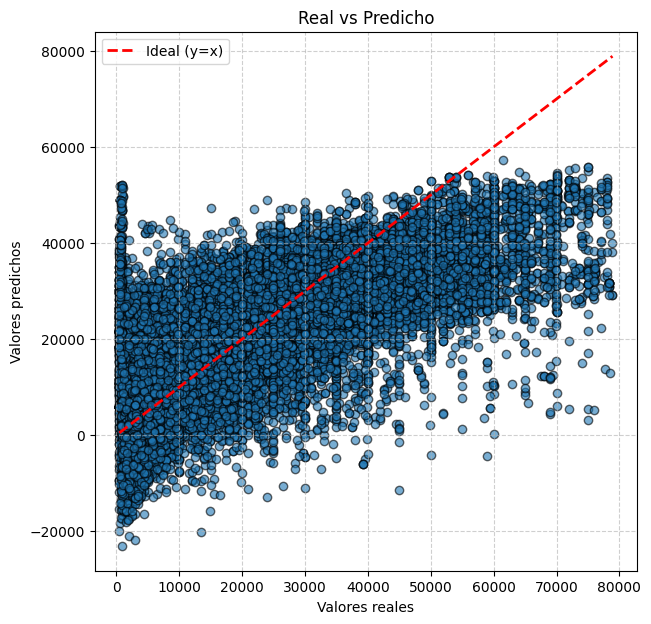

Tabla de importancia de variables:
                   feature          coef  importance_abs
45           fuel_electric -17407.822266    17407.822266
41      manufacturer_tesla  15596.821289    15596.821289
47             fuel_hybrid -14406.367188    14406.367188
46                fuel_gas -14344.550781    14344.550781
48              fuel_other -11827.091797    11827.091797
..                     ...           ...             ...
114     paint_color_orange   -145.266266      145.266266
75      paint_color_orange   -144.354752      144.354752
9    manufacturer_cadillac   -103.650116      103.650116
27    manufacturer_lincoln    -86.763512       86.763512
22     manufacturer_jaguar     80.546196       80.546196

[170 rows x 3 columns]


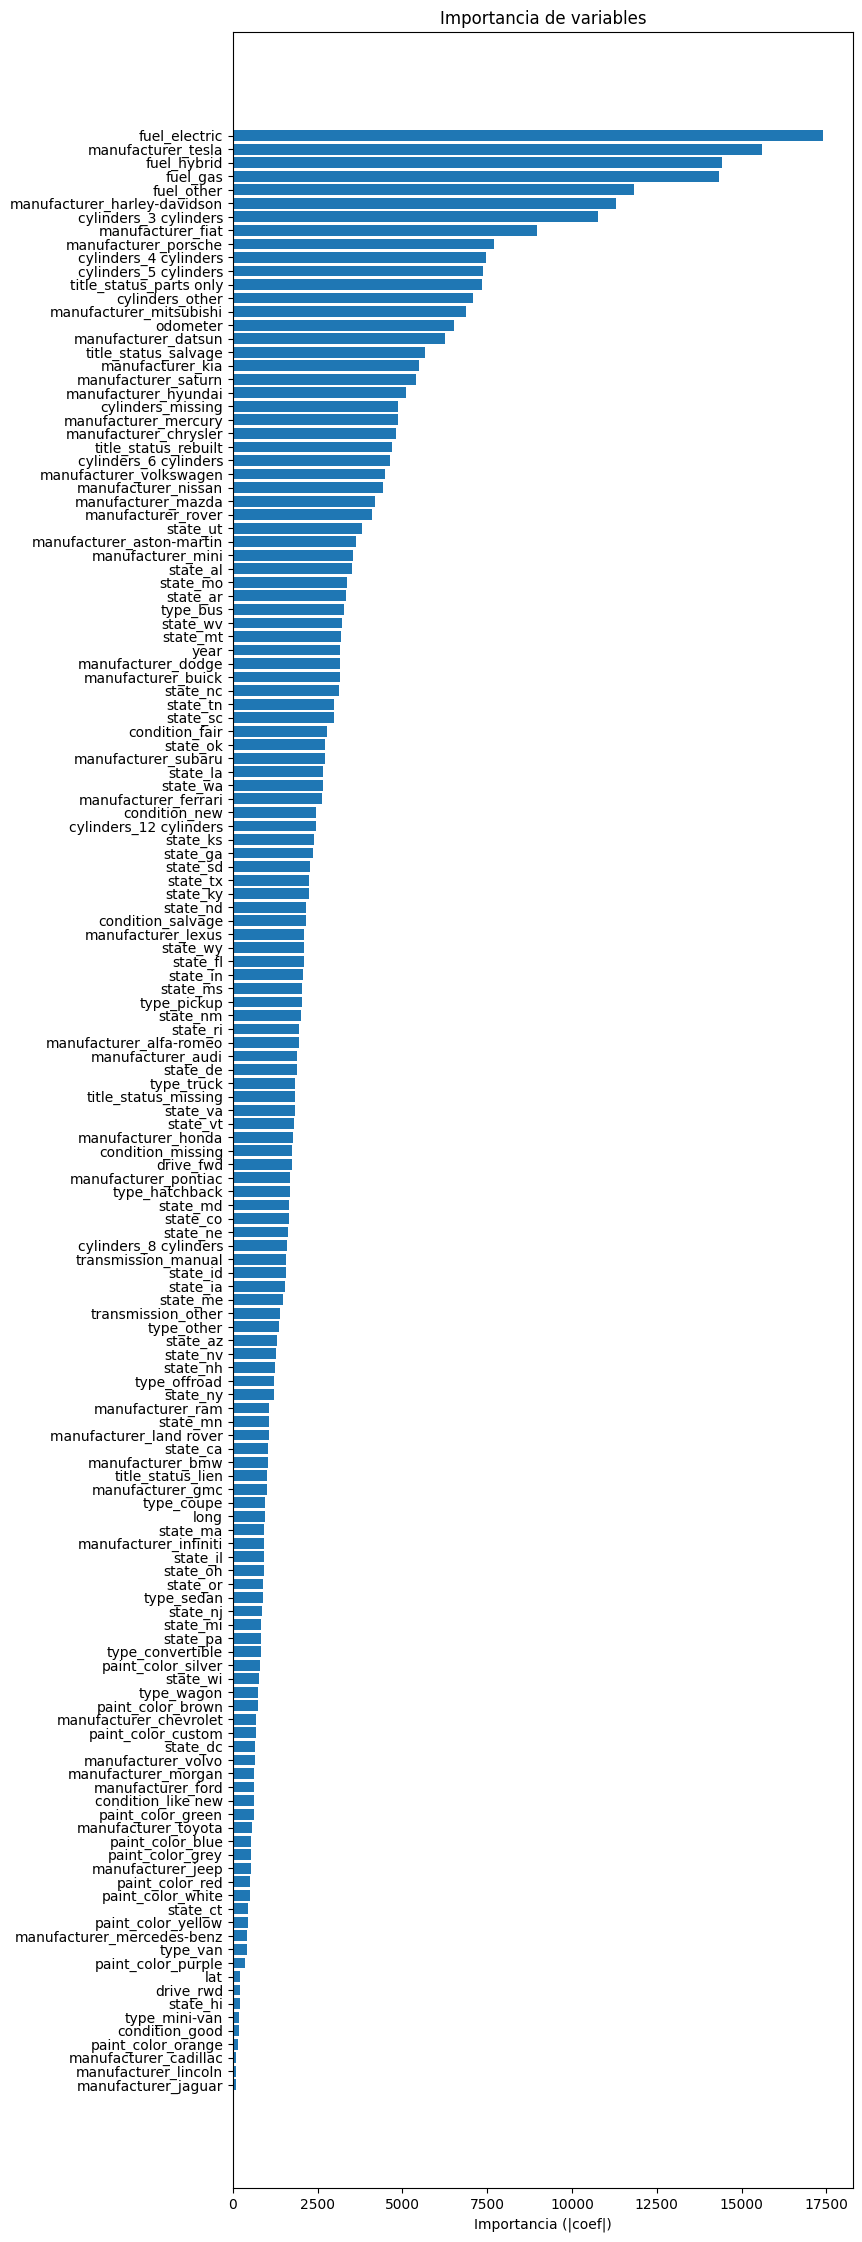

In [88]:
best_ridge = grid_ridge.best_estimator_
importances = analizar_modelo_lineal(best_ridge, X_train_reg_final, X_test_reg_final, y_test_reg)

### MAE

In [89]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=0)

In [90]:
param_grid_reg = {'alpha':[0.1, 1, 10, 100, 1000]}

In [91]:
ridge_search=Ridge(max_iter=1000, random_state=0)

In [92]:
grid_ridge = GridSearchCV(ridge_search, param_grid_reg, cv=cv_reg, scoring='neg_mean_absolute_error')

In [93]:
grid_ridge.fit(X_train_reg_final, y_train_reg)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.52758e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.07639e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Ridge(max_iter=1000, random_state=0),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_absolute_error')

In [94]:
print("Mejor alpha Ridge: MAE", grid_ridge.best_params_['alpha'])
print("Mejor score Ridge: MAE", -grid_ridge.best_score_)

Mejor alpha Ridge: MAE 10
Mejor score Ridge: MAE 6005.715720650408


#### Comparacion real contra predicho e importancia de coeficientes

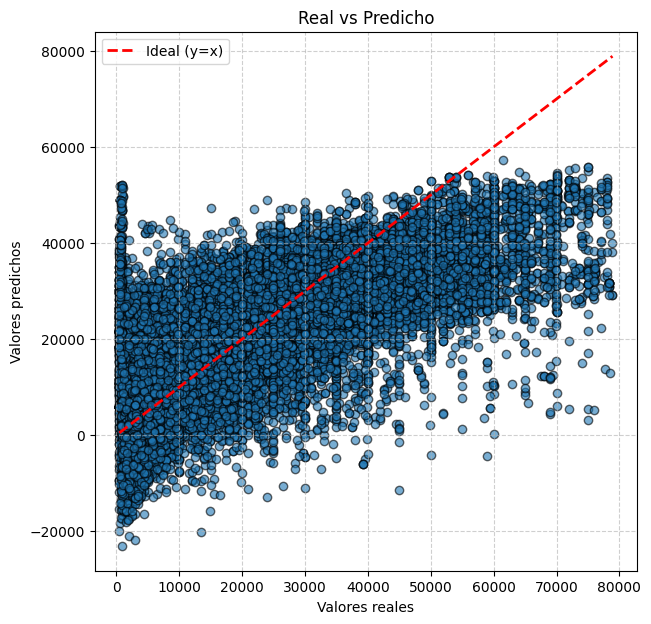

Tabla de importancia de variables:
                   feature          coef  importance_abs
45           fuel_electric -17407.822266    17407.822266
41      manufacturer_tesla  15596.821289    15596.821289
47             fuel_hybrid -14406.367188    14406.367188
46                fuel_gas -14344.550781    14344.550781
48              fuel_other -11827.091797    11827.091797
..                     ...           ...             ...
114     paint_color_orange   -145.266266      145.266266
75      paint_color_orange   -144.354752      144.354752
9    manufacturer_cadillac   -103.650116      103.650116
27    manufacturer_lincoln    -86.763512       86.763512
22     manufacturer_jaguar     80.546196       80.546196

[170 rows x 3 columns]


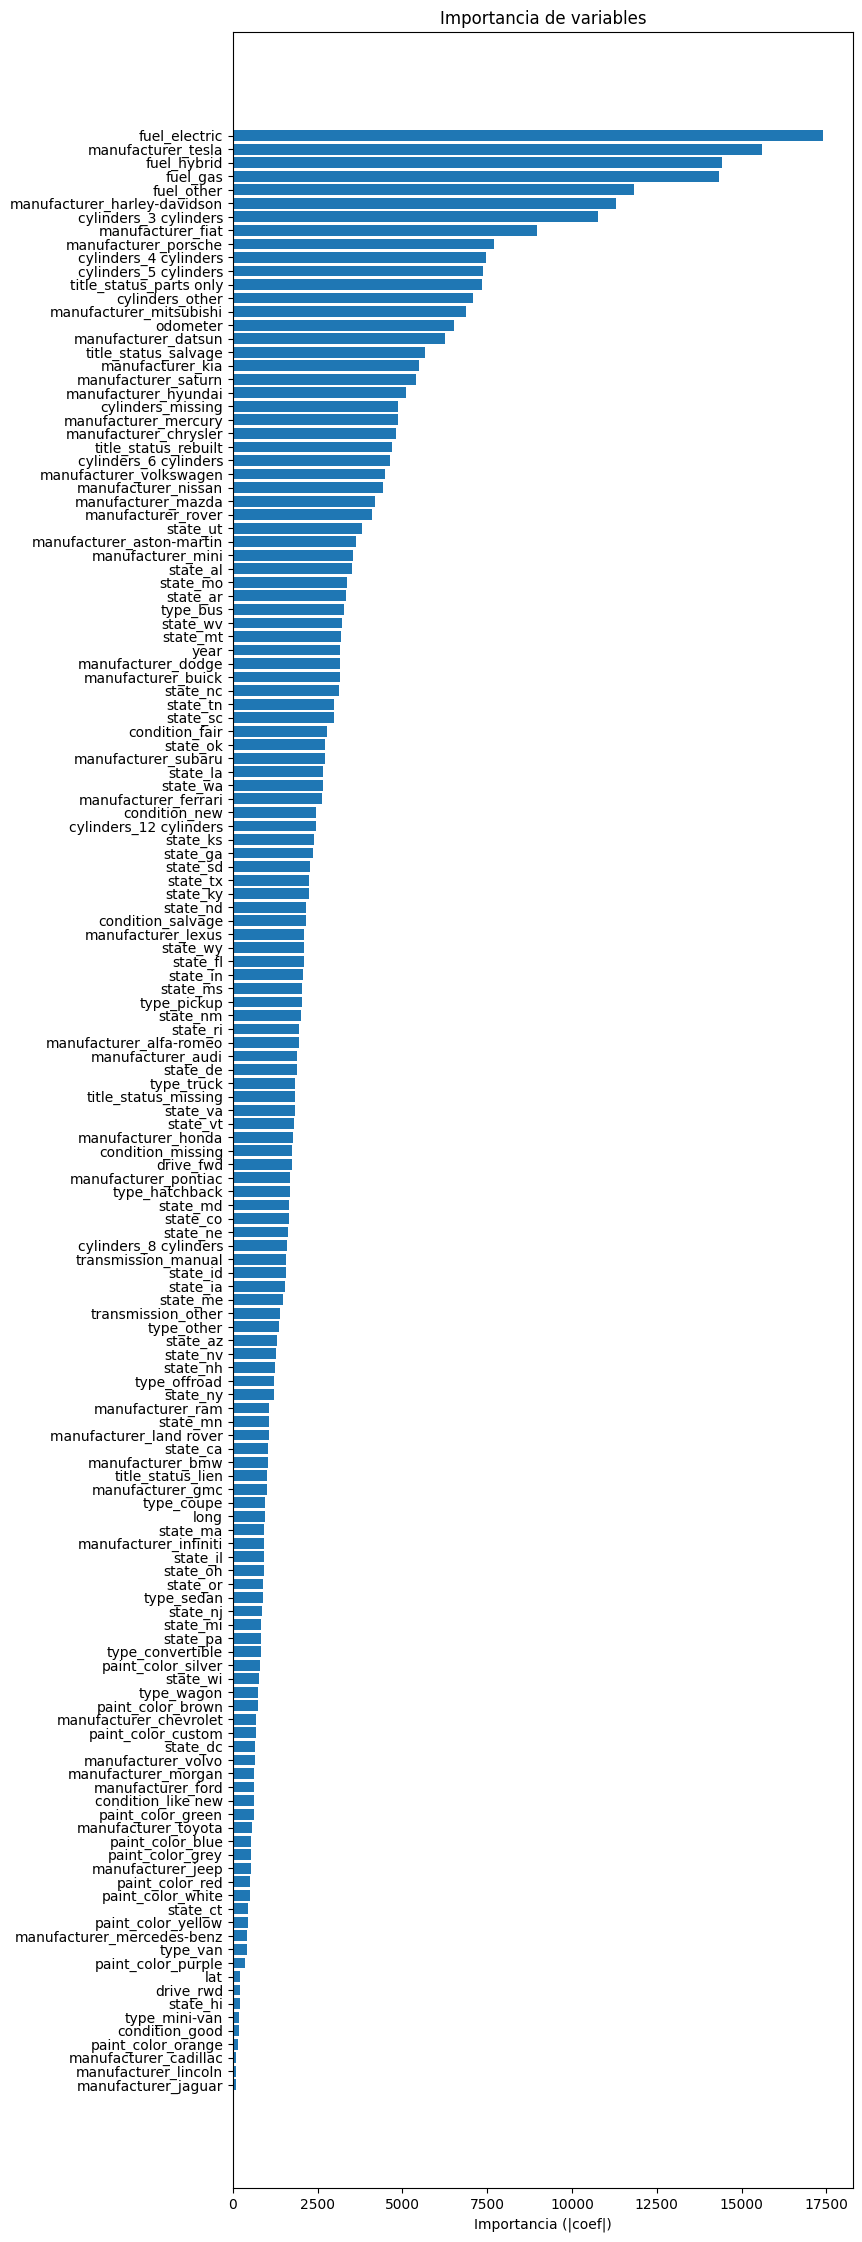

In [95]:
best_ridge = grid_ridge.best_estimator_
importances = analizar_modelo_lineal(best_ridge, X_train_reg_final, X_test_reg_final, y_test_reg)

### RMSE

In [96]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=0)

In [97]:
param_grid_reg = {'alpha':[0.1, 1, 10, 100, 1000]}

In [98]:
ridge_search=Ridge(max_iter=1000, random_state=0)

In [99]:
grid_ridge = GridSearchCV(ridge_search, param_grid_reg, cv=cv_reg, scoring='neg_root_mean_squared_error')

In [100]:
grid_ridge.fit(X_train_reg_final, y_train_reg)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.52758e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.07639e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Ridge(max_iter=1000, random_state=0),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]},
             scoring='neg_root_mean_squared_error')

In [101]:
print("Mejor alpha Ridge: RMSE", grid_ridge.best_params_['alpha'])
print("Mejor score Ridge: RMSE", -grid_ridge.best_score_)

Mejor alpha Ridge: RMSE 10
Mejor score Ridge: RMSE 8521.239242002714


#### Comparacion valor real contra valor predicho e importancia de coeficientes

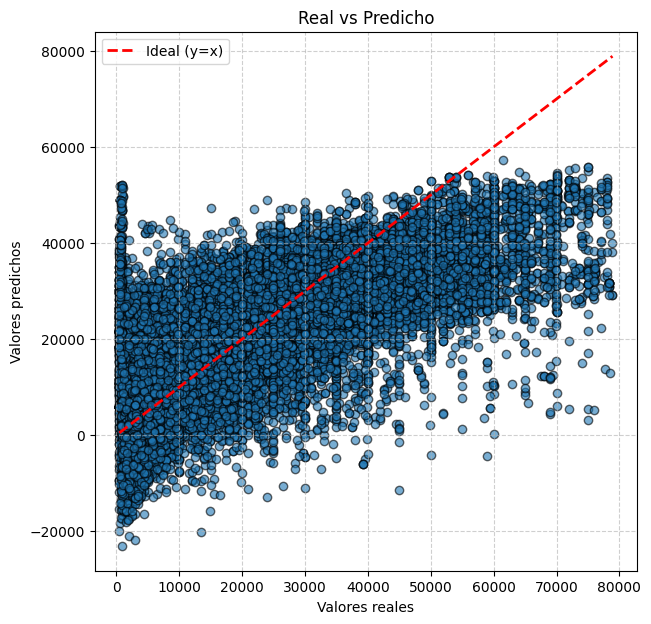

Tabla de importancia de variables:
                   feature          coef  importance_abs
45           fuel_electric -17407.822266    17407.822266
41      manufacturer_tesla  15596.821289    15596.821289
47             fuel_hybrid -14406.367188    14406.367188
46                fuel_gas -14344.550781    14344.550781
48              fuel_other -11827.091797    11827.091797
..                     ...           ...             ...
114     paint_color_orange   -145.266266      145.266266
75      paint_color_orange   -144.354752      144.354752
9    manufacturer_cadillac   -103.650116      103.650116
27    manufacturer_lincoln    -86.763512       86.763512
22     manufacturer_jaguar     80.546196       80.546196

[170 rows x 3 columns]


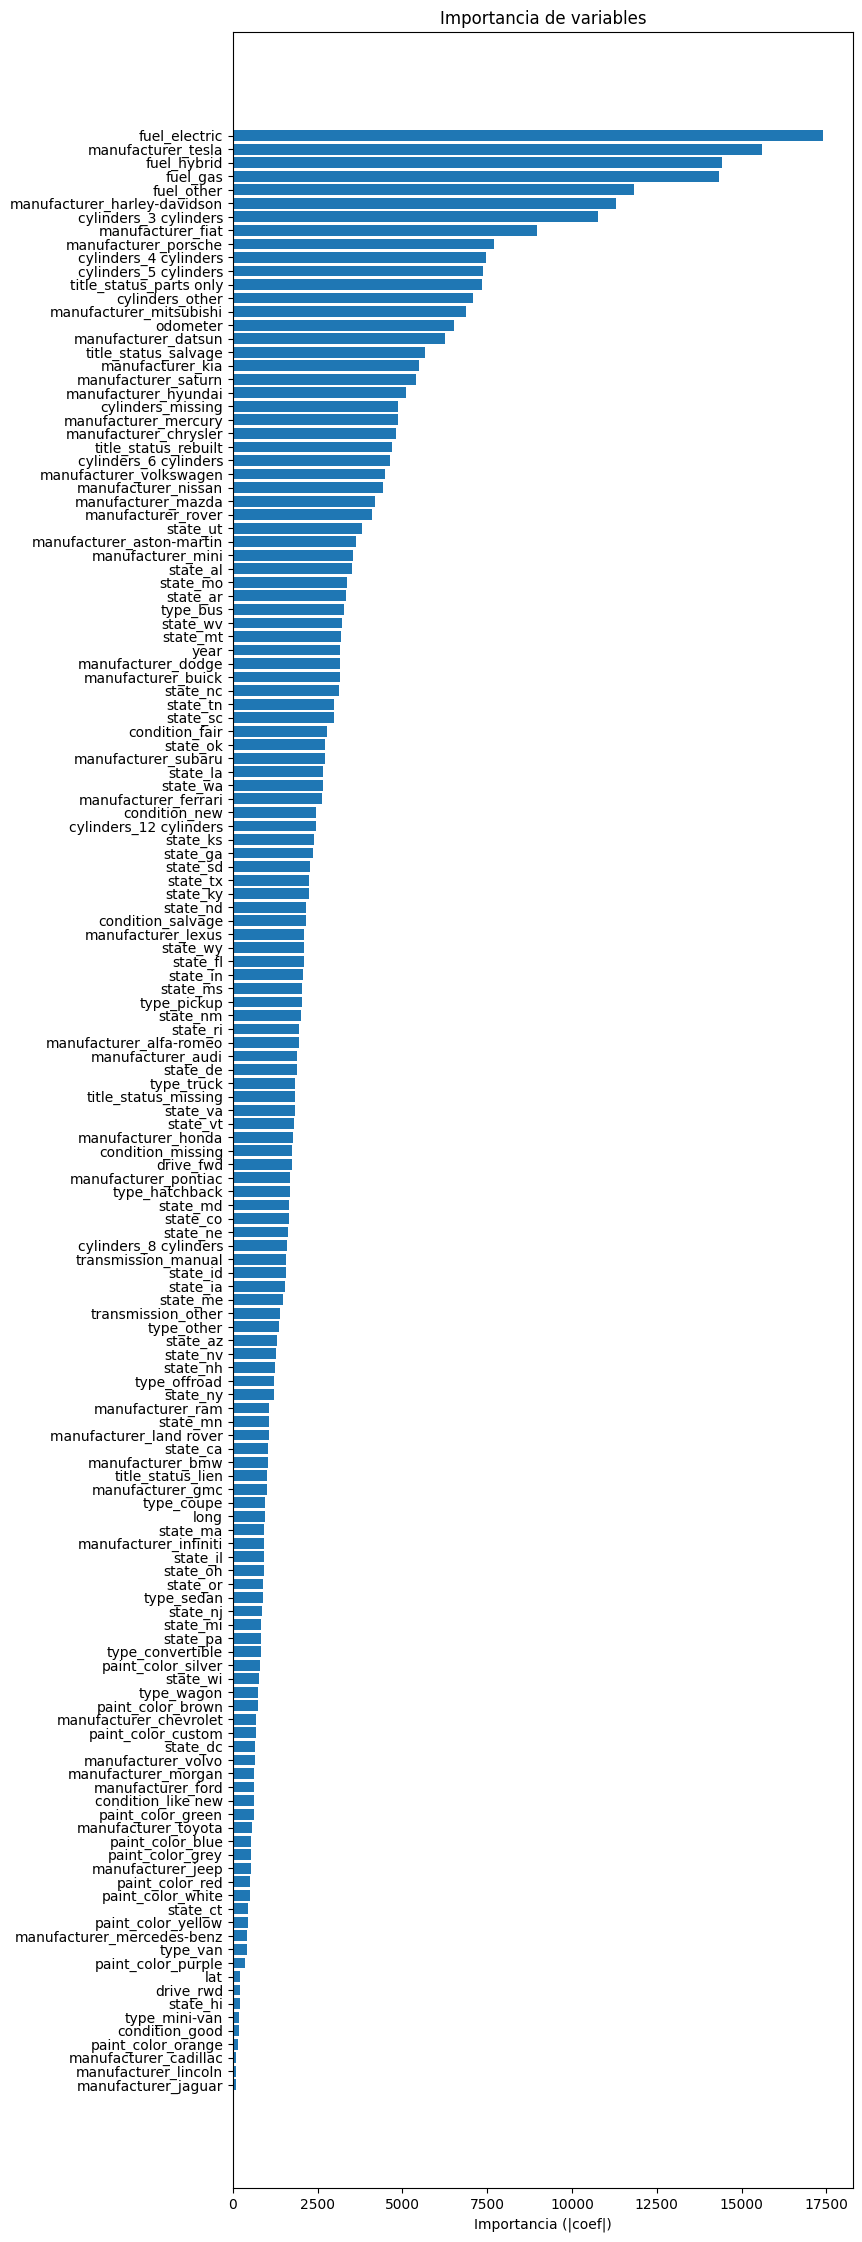

In [102]:
best_ridge = grid_ridge.best_estimator_
importances = analizar_modelo_lineal(best_ridge, X_train_reg_final, X_test_reg_final, y_test_reg)

## Busqueda de hiperparametro alpha lasso

### R2

In [103]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=0)

In [104]:
param_grid_reg = {'alpha':[0.1, 1, 10, 100, 1000]}

In [105]:
lasso_search=Lasso(max_iter=10000, random_state=0)

In [106]:
grid_lasso = GridSearchCV(lasso_search, param_grid_reg, cv=cv_reg, scoring='r2')

In [107]:
grid_lasso.fit(X_train_reg_final, y_train_reg)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Lasso(max_iter=10000, random_state=0),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]}, scoring='r2')

In [108]:
print("Mejor alpha Lasso:", grid_lasso.best_params_['alpha'])
print("Mejor score Lasso:", grid_lasso.best_score_)

Mejor alpha Lasso: 0.1
Mejor score Lasso: 0.6195616178538177


#### Comparacion real contra predicho e importancia de coeficientes

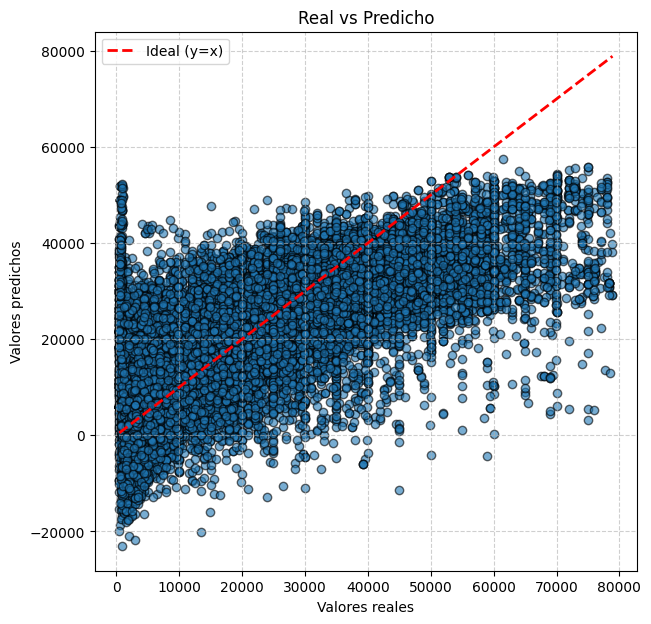

Tabla de importancia de variables:
                          feature          coef  importance_abs
45                  fuel_electric -17747.027344    17747.027344
41             manufacturer_tesla  16013.404297    16013.404297
47                    fuel_hybrid -14475.663086    14475.663086
46                       fuel_gas -14375.731445    14375.731445
18   manufacturer_harley-davidson -12056.959961    12056.959961
..                            ...           ...             ...
25        manufacturer_land rover      0.000000        0.000000
62                  type_mini-van      0.000000        0.000000
113              paint_color_grey     -0.000000        0.000000
117            paint_color_silver     -0.000000        0.000000
106                    type_truck      0.000000        0.000000

[170 rows x 3 columns]


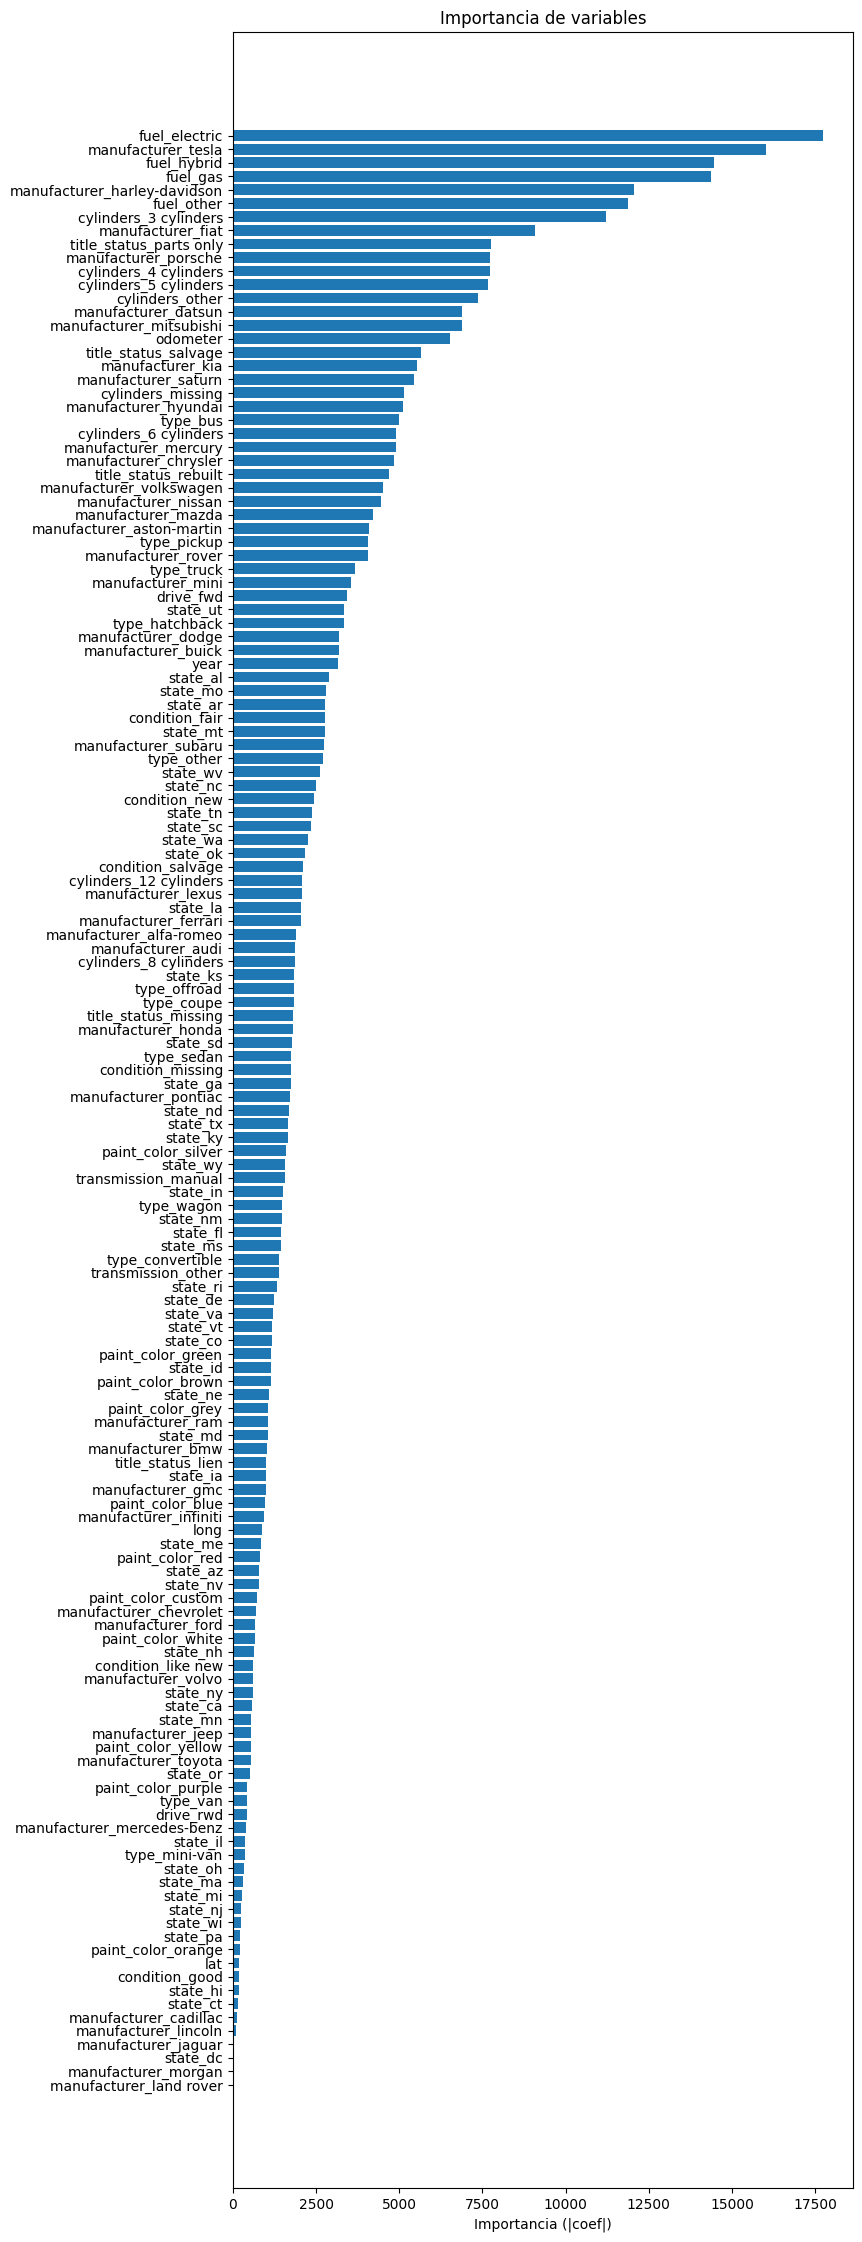

In [109]:
# Usamos el mejor modelo encontrado
best_lasso = grid_lasso.best_estimator_

importances = analizar_modelo_lineal(best_lasso, X_train_reg_final, X_test_reg_final, y_test_reg)

### MAE

In [110]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=0)

In [111]:
param_grid_reg = {'alpha':[0.1, 1, 10, 100, 1000]}

In [112]:
lasso_search=Lasso(max_iter=10000, random_state=0)

In [113]:
grid_lasso = GridSearchCV(lasso_search, param_grid_reg, cv=cv_reg, scoring='neg_mean_absolute_error')

In [114]:
grid_lasso.fit(X_train_reg_final, y_train_reg)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Lasso(max_iter=10000, random_state=0),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_absolute_error')

In [115]:
print("Mejor alpha Lasso:", grid_lasso.best_params_['alpha'])
print("Mejor score Lasso:", -grid_lasso.best_score_)

Mejor alpha Lasso: 0.1
Mejor score Lasso: 6005.560564759132


#### Comparacion predicho contra real e importancia de coeficientes

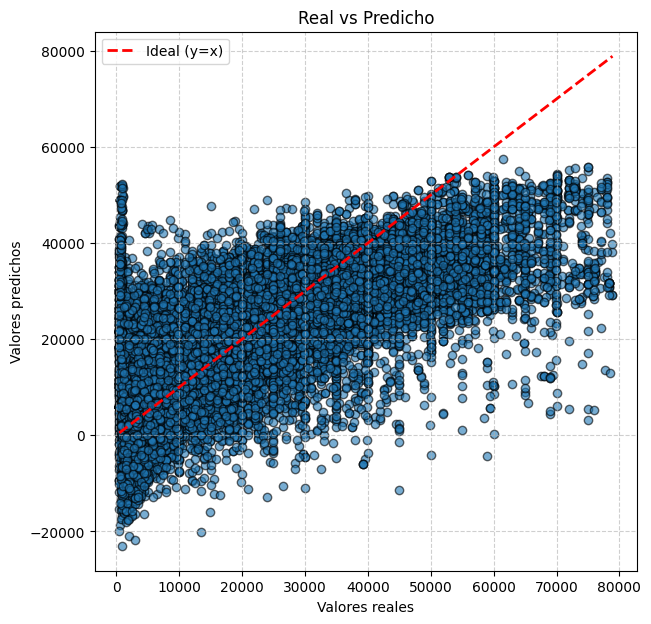

Tabla de importancia de variables:
                          feature          coef  importance_abs
45                  fuel_electric -17747.027344    17747.027344
41             manufacturer_tesla  16013.404297    16013.404297
47                    fuel_hybrid -14475.663086    14475.663086
46                       fuel_gas -14375.731445    14375.731445
18   manufacturer_harley-davidson -12056.959961    12056.959961
..                            ...           ...             ...
25        manufacturer_land rover      0.000000        0.000000
62                  type_mini-van      0.000000        0.000000
113              paint_color_grey     -0.000000        0.000000
117            paint_color_silver     -0.000000        0.000000
106                    type_truck      0.000000        0.000000

[170 rows x 3 columns]


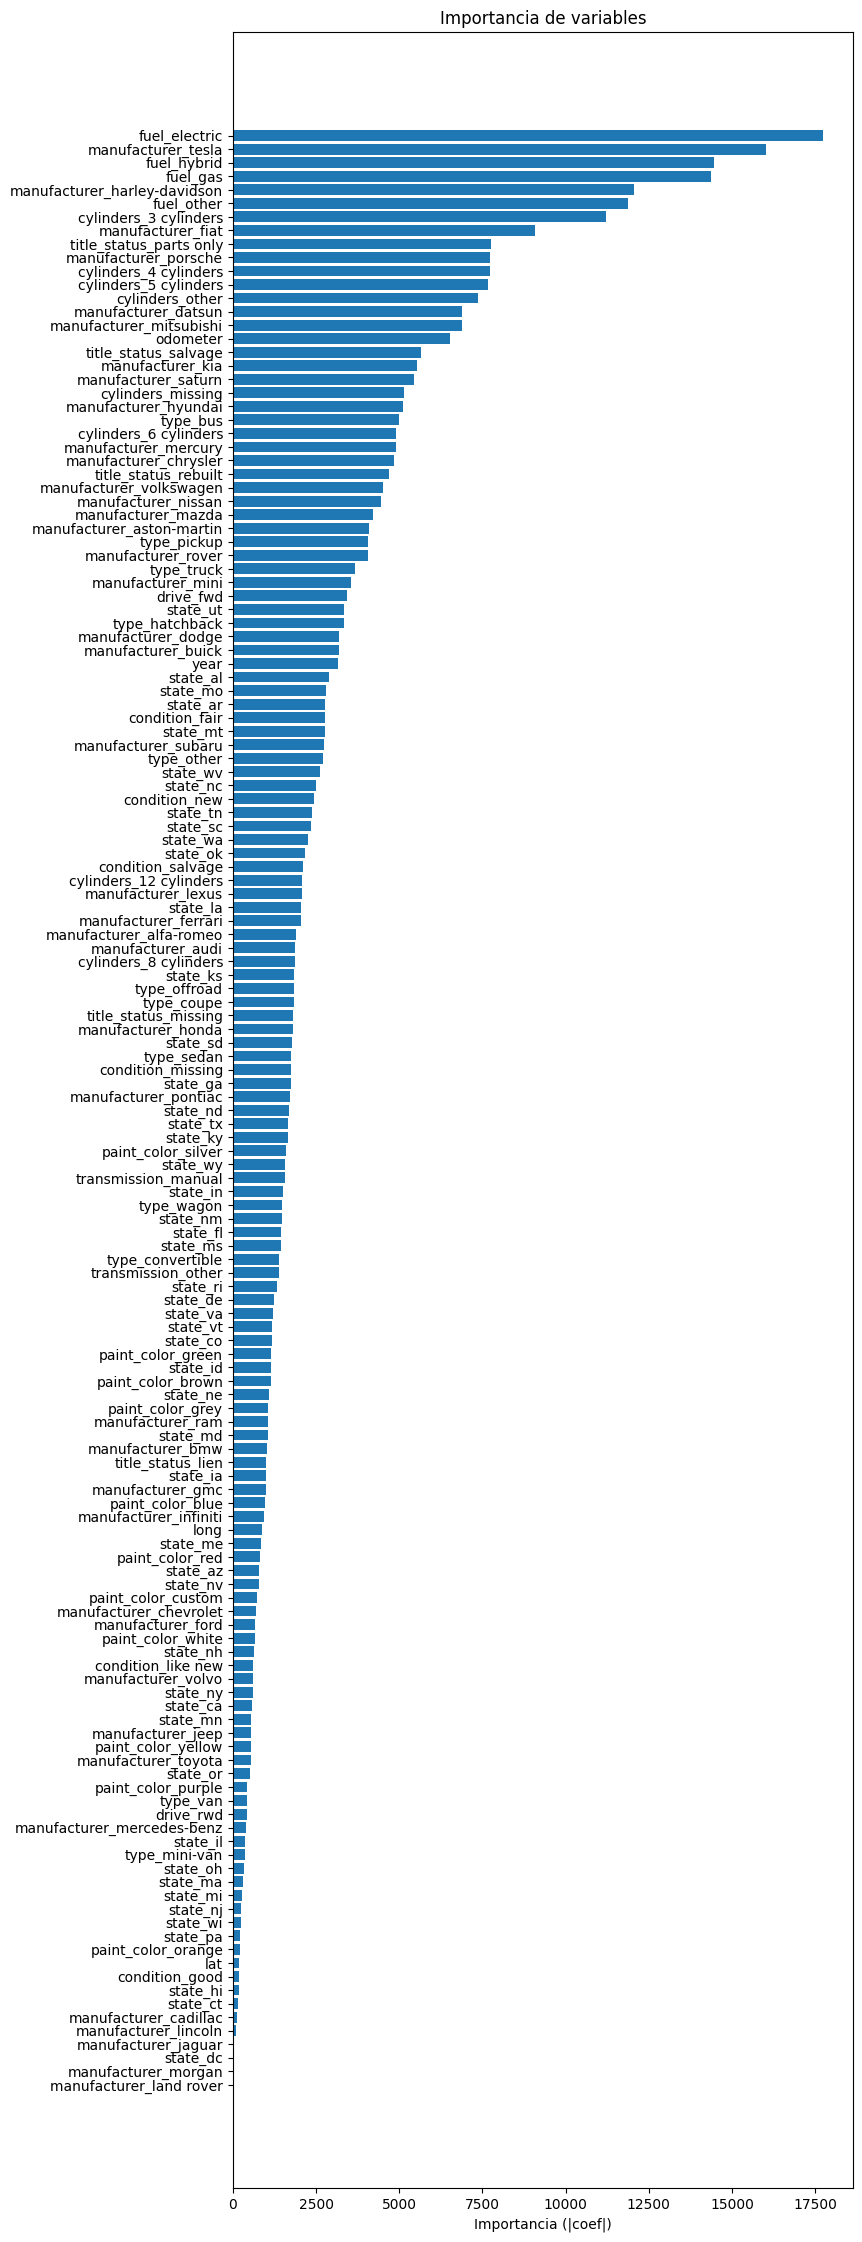

In [116]:
best_lasso = grid_lasso.best_estimator_

importances = analizar_modelo_lineal(best_lasso, X_train_reg_final, X_test_reg_final, y_test_reg)

### RMSE

In [117]:
cv_reg = KFold(n_splits=5, shuffle=True, random_state=0)

In [118]:
param_grid_reg = {'alpha':[0.1, 1, 10, 100, 1000]}

In [119]:
lasso_search=Lasso(max_iter=10000, random_state=0)

In [120]:
grid_lasso = GridSearchCV(lasso_search, param_grid_reg, cv=cv_reg, scoring='neg_root_mean_squared_error')

In [121]:
grid_lasso.fit(X_train_reg_final, y_train_reg)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Lasso(max_iter=10000, random_state=0),
             param_grid={'alpha': [0.1, 1, 10, 100, 1000]},
             scoring='neg_root_mean_squared_error')

In [122]:
print("Mejor alpha Lasso:", grid_lasso.best_params_['alpha'])
print("Mejor score Lasso:", -grid_lasso.best_score_)

Mejor alpha Lasso: 0.1
Mejor score Lasso: 8521.593725833529


#### comparacion valor real contra valor predicho e importancia de coeficientes

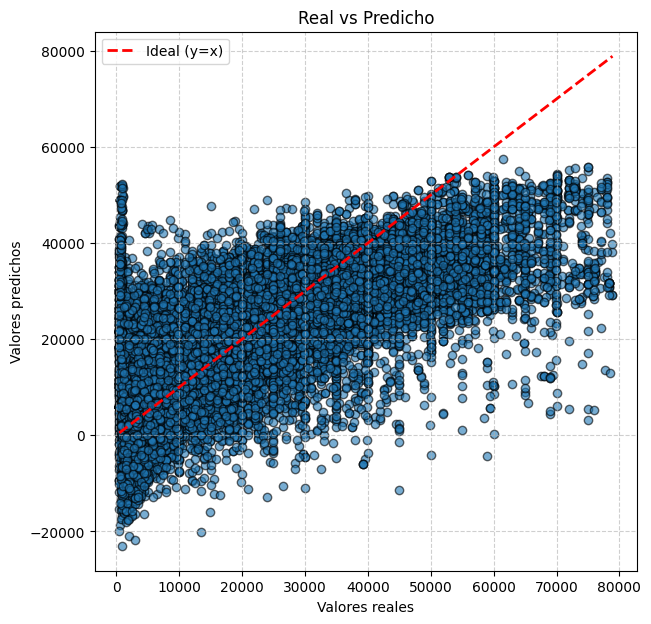

Tabla de importancia de variables:
                          feature          coef  importance_abs
45                  fuel_electric -17747.027344    17747.027344
41             manufacturer_tesla  16013.404297    16013.404297
47                    fuel_hybrid -14475.663086    14475.663086
46                       fuel_gas -14375.731445    14375.731445
18   manufacturer_harley-davidson -12056.959961    12056.959961
..                            ...           ...             ...
25        manufacturer_land rover      0.000000        0.000000
62                  type_mini-van      0.000000        0.000000
113              paint_color_grey     -0.000000        0.000000
117            paint_color_silver     -0.000000        0.000000
106                    type_truck      0.000000        0.000000

[170 rows x 3 columns]


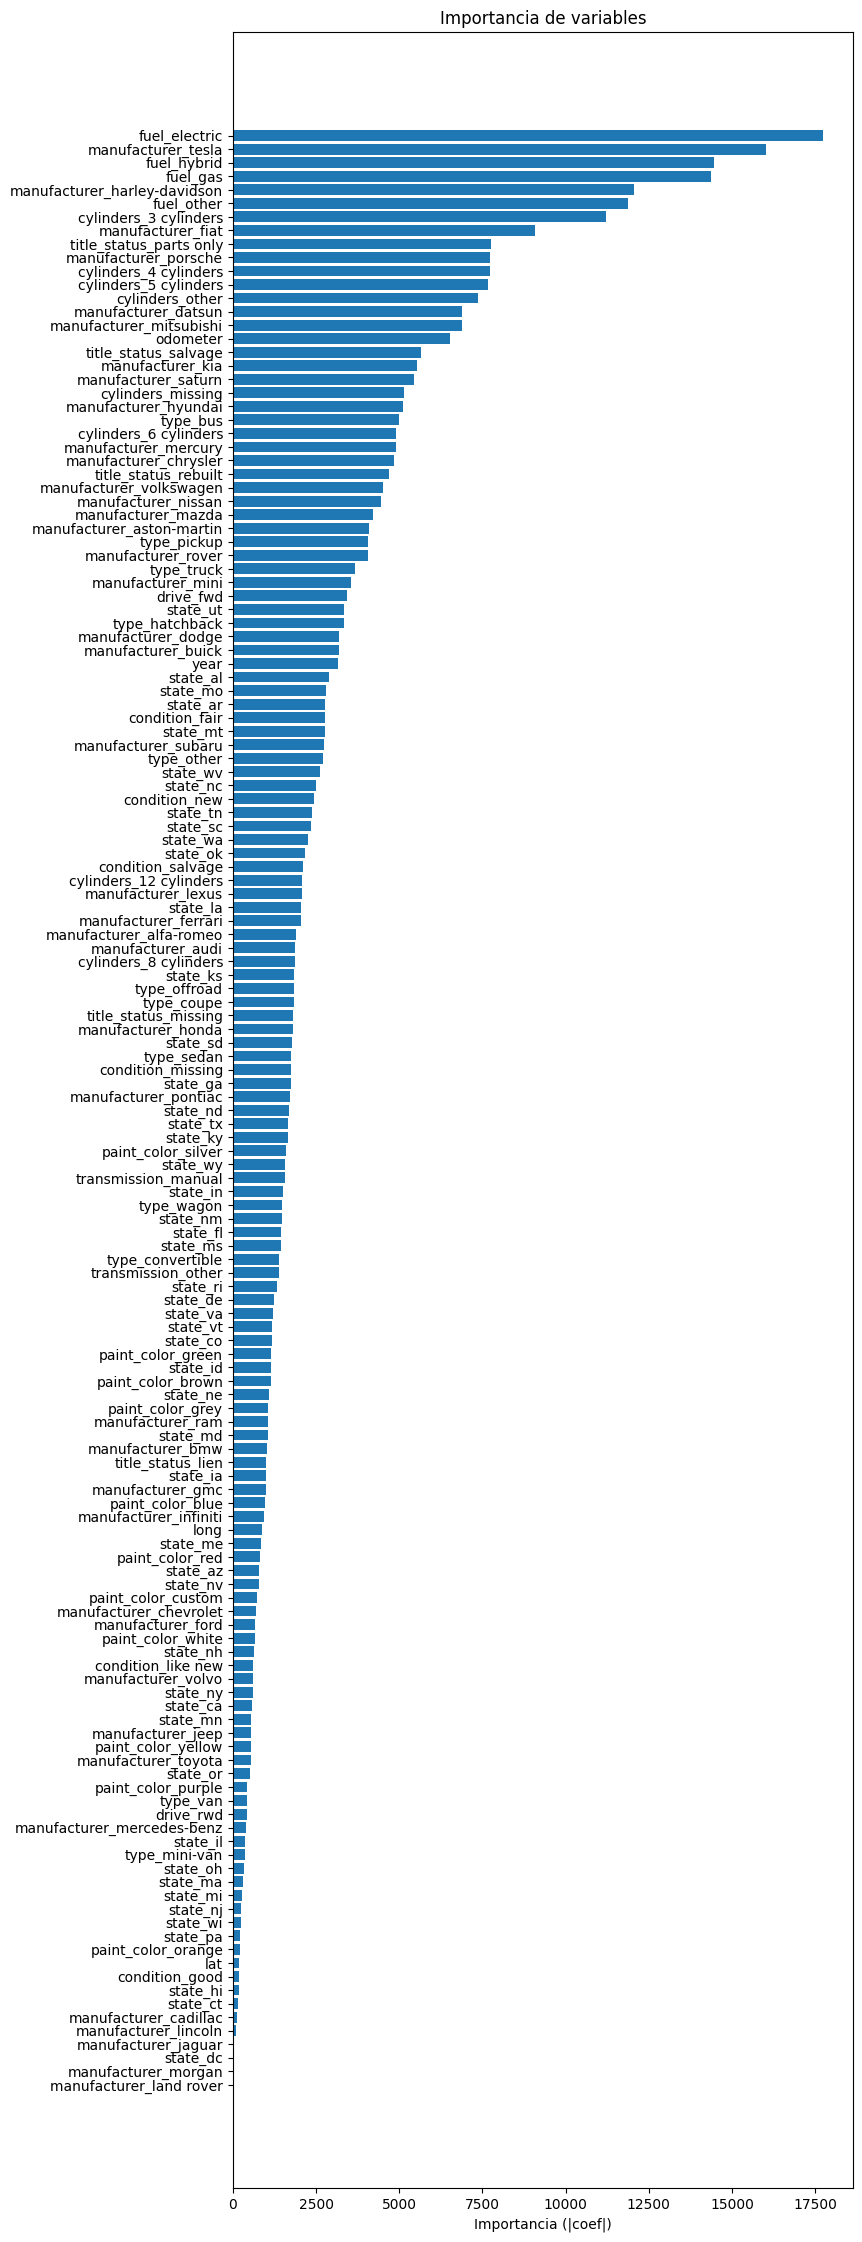

In [123]:
# Usamos el mejor modelo encontrado
best_lasso = grid_lasso.best_estimator_

importances = analizar_modelo_lineal(best_lasso, X_train_reg_final, X_test_reg_final, y_test_reg)

## Busqueda de Hiperparametro C

Se realiza la busqueda mediante GridSearch del hiperparametro C para el modelo de regresion Logistica

### Accuracy

In [124]:
log_reg = LogisticRegression(max_iter=1000, solver='saga',random_state=0)
param_grid = {'C': [0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)                                              
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy'
) 
grid_search.fit(X_train_clas_final, y_train_clas)             
print("Mejor hiperparámetro C:", grid_search.best_params_)
print("Mejor score de validación:", grid_search.best_score_)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Mejor hiperparámetro C: {'C': 100}
Mejor score de validación: 0.8322470467859724


#### Curva roc, calculo de AUC y coeficientes del mejor modelo

AUC: 0.9080331610375669


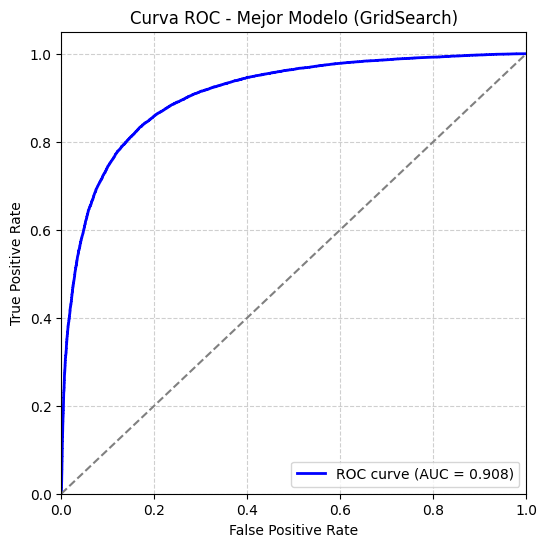


Tabla de importancia de variables:
                feature      coef  importance_abs
44        fuel_electric -4.639987        4.639987
46          fuel_hybrid -3.748278        3.748278
40   manufacturer_tesla  3.090961        3.090961
55       condition_fair -2.968728        2.968728
45             fuel_gas -2.900606        2.900606
..                  ...       ...             ...
59        condition_new  0.032982        0.032982
106            state_wi  0.026179        0.026179
43   manufacturer_volvo -0.023234        0.023234
2                   lat -0.015442        0.015442
57   condition_like new  0.001374        0.001374

[109 rows x 3 columns]


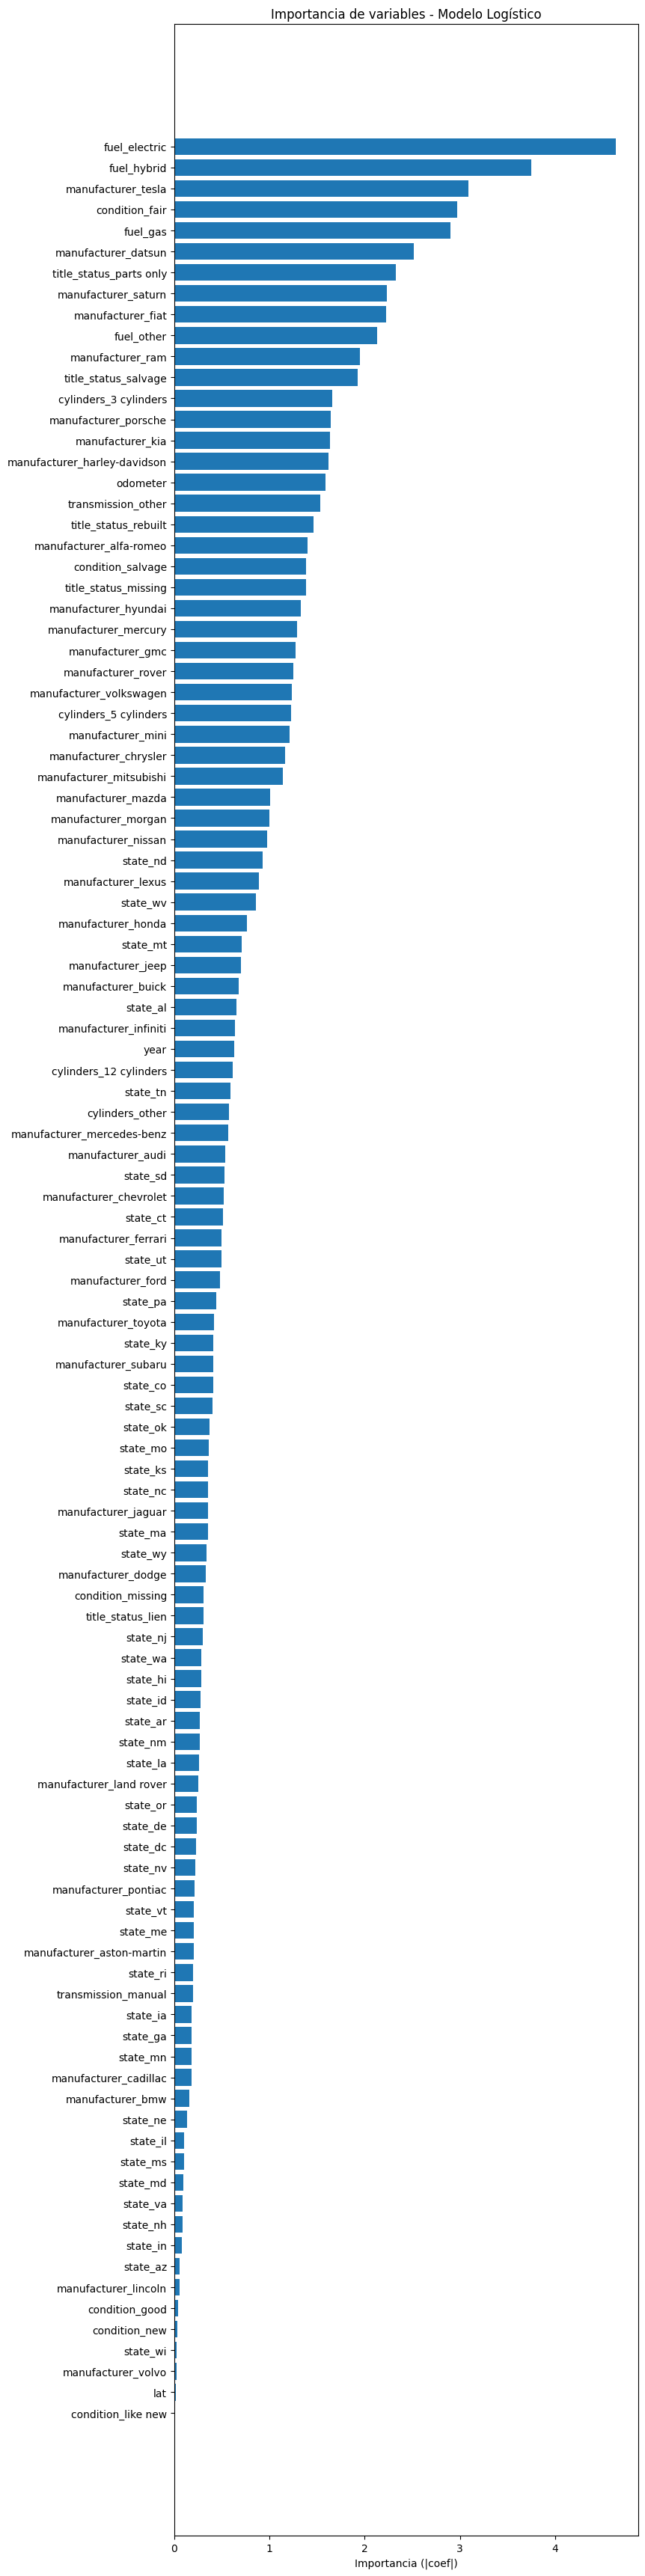

In [125]:
best_model = grid_search.best_estimator_
importances = analizar_modelo_clasificacion(best_model, X_train_clas_final, X_test_clas_final, y_test_clas)

In [126]:
Reporte_clasificacion(best_model, X_test_clas_final, y_test_clas)

Accuracy: 0.8311552466070837
Precision: 0.8312570102291365
Recall: 0.8311552466070837
F1-score: 0.8311422535576924

Matriz de confusión:
[[31718  6045]
 [ 6707 31055]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     37763
           1       0.84      0.82      0.83     37762

    accuracy                           0.83     75525
   macro avg       0.83      0.83      0.83     75525
weighted avg       0.83      0.83      0.83     75525



### Precision

In [127]:
log_reg = LogisticRegression(max_iter=1000, solver='saga',random_state=0)
param_grid = {'C': [0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)                                              
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv,
    scoring='precision'
) 
grid_search.fit(X_train_clas_final, y_train_clas)             
print("Mejor hiperparámetro C:", grid_search.best_params_)
print("Mejor score de validación:", grid_search.best_score_)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Mejor hiperparámetro C: {'C': 0.1}
Mejor score de validación: 0.8370059454349874


c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


#### Curva ROC, Calculo del AUC y coeficientes del mejor modelo

AUC: 0.9078463449062514


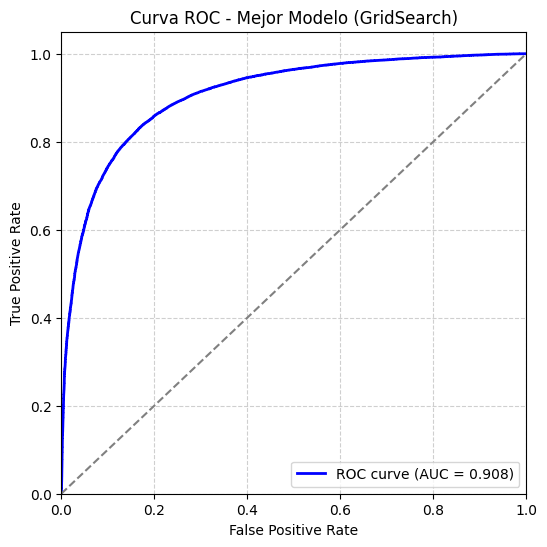


Tabla de importancia de variables:
                  feature      coef  importance_abs
44          fuel_electric -4.180757        4.180757
46            fuel_hybrid -3.588932        3.588932
45               fuel_gas -2.814513        2.814513
55         condition_fair -2.522620        2.522620
40     manufacturer_tesla  2.176241        2.176241
..                    ...       ...             ...
59          condition_new  0.029049        0.029049
106              state_wi  0.021773        0.021773
26   manufacturer_lincoln  0.019758        0.019758
2                     lat -0.014959        0.014959
57     condition_like new  0.003759        0.003759

[109 rows x 3 columns]


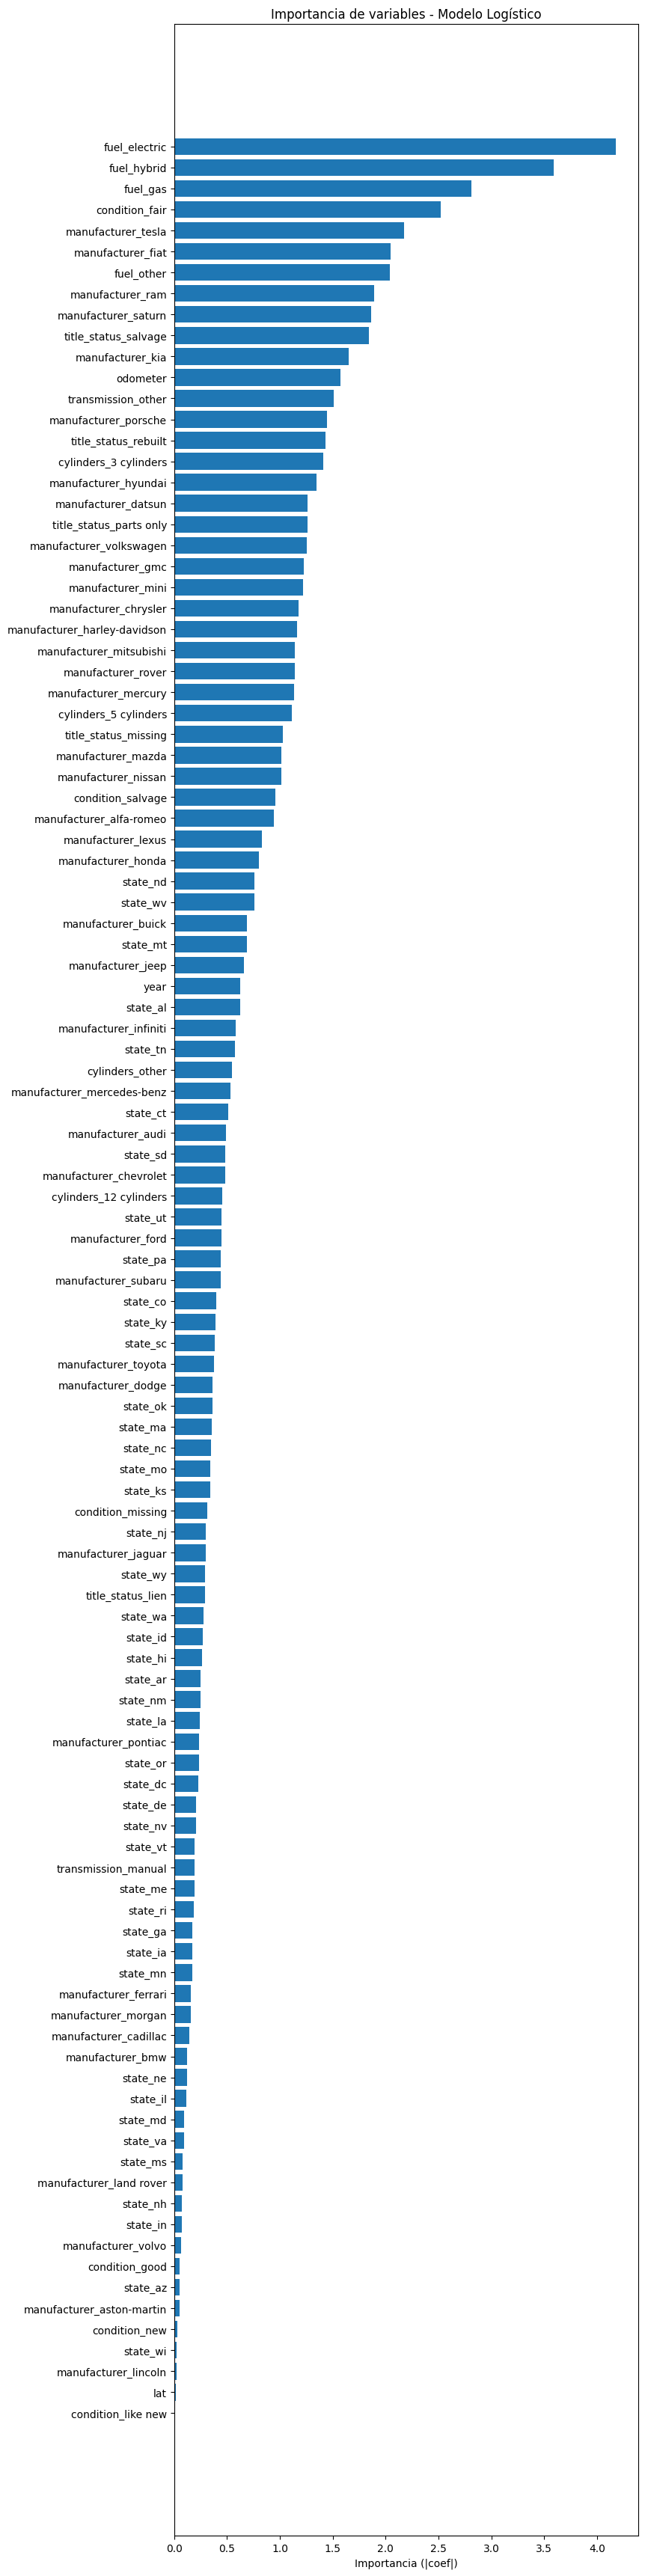

In [128]:
best_model = grid_search.best_estimator_
importances = analizar_modelo_clasificacion(best_model, X_train_clas_final, X_test_clas_final, y_test_clas)

In [129]:
Reporte_clasificacion(best_model, X_test_clas_final, y_test_clas)

Accuracy: 0.8309963588215823
Precision: 0.8311043155645602
Recall: 0.8309963588215823
F1-score: 0.8309825564030914

Matriz de confusión:
[[31722  6041]
 [ 6723 31039]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     37763
           1       0.84      0.82      0.83     37762

    accuracy                           0.83     75525
   macro avg       0.83      0.83      0.83     75525
weighted avg       0.83      0.83      0.83     75525



### recall

In [130]:
log_reg = LogisticRegression(max_iter=1000, solver='saga',random_state=0)
param_grid = {'C': [0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)                                              
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv,
    scoring='recall'
) 
grid_search.fit(X_train_clas_final, y_train_clas)             
print("Mejor hiperparámetro C:", grid_search.best_params_)
print("Mejor score de validación:", grid_search.best_score_)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Mejor hiperparámetro C: {'C': 1}
Mejor score de validación: 0.8252234359483615


#### Curva roc, calculo del AUC y coeficientes del mejor modelo

AUC: 0.9080325698761272


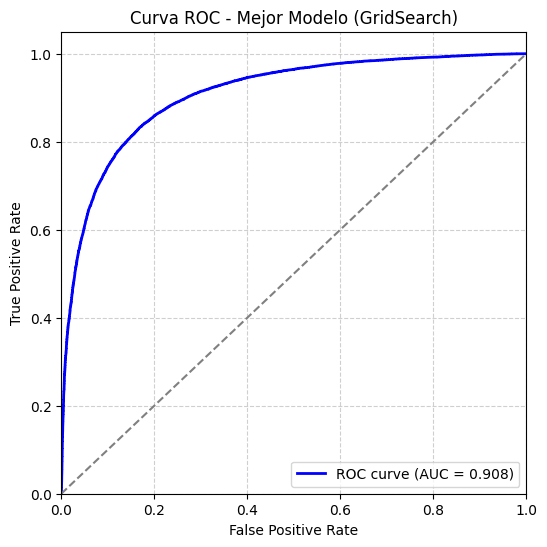


Tabla de importancia de variables:
                feature      coef  importance_abs
44        fuel_electric -4.638968        4.638968
46          fuel_hybrid -3.747556        3.747556
40   manufacturer_tesla  3.085721        3.085721
55       condition_fair -2.967355        2.967355
45             fuel_gas -2.900400        2.900400
..                  ...       ...             ...
59        condition_new  0.032914        0.032914
106            state_wi  0.026166        0.026166
43   manufacturer_volvo -0.022146        0.022146
2                   lat -0.015446        0.015446
57   condition_like new  0.001360        0.001360

[109 rows x 3 columns]


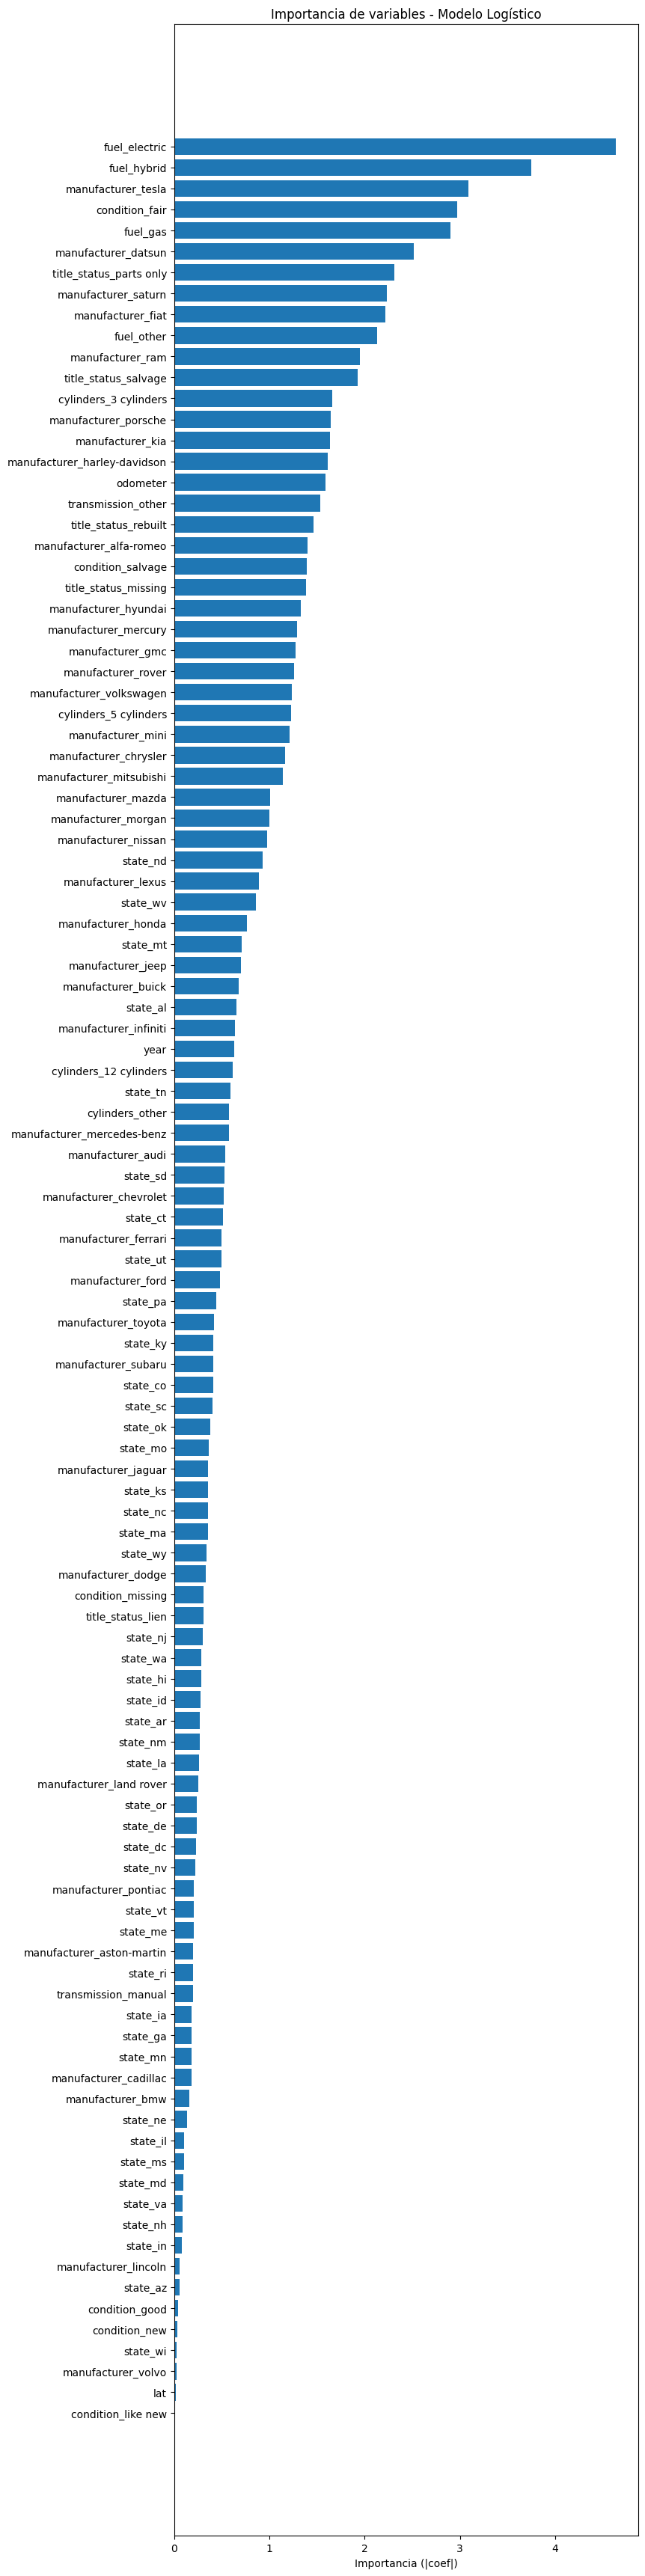

In [131]:
best_model = grid_search.best_estimator_
importances = analizar_modelo_clasificacion(best_model, X_train_clas_final, X_test_clas_final, y_test_clas)

In [132]:
Reporte_clasificacion(best_model, X_test_clas_final, y_test_clas)

Accuracy: 0.8311552466070837
Precision: 0.8312576263533012
Recall: 0.8311552466070837
F1-score: 0.8311421749845476

Matriz de confusión:
[[31719  6044]
 [ 6708 31054]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     37763
           1       0.84      0.82      0.83     37762

    accuracy                           0.83     75525
   macro avg       0.83      0.83      0.83     75525
weighted avg       0.83      0.83      0.83     75525



### F1-score

In [133]:
log_reg = LogisticRegression(max_iter=1000, solver='saga',random_state=0)
param_grid = {'C': [0.1, 1, 10, 100]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)                                              
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv,
    scoring='f1'
) 
grid_search.fit(X_train_clas_final, y_train_clas)             
print("Mejor hiperparámetro C:", grid_search.best_params_)
print("Mejor score de validación:", grid_search.best_score_)

c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\migue\miniconda3\envs\ml_venv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Mejor hiperparámetro C: {'C': 1}
Mejor score de validación: 0.8310579367143973


#### Curva roc, calculo del AUC y coeficientes para el mejor modelo F1-score

AUC: 0.9080325698761272


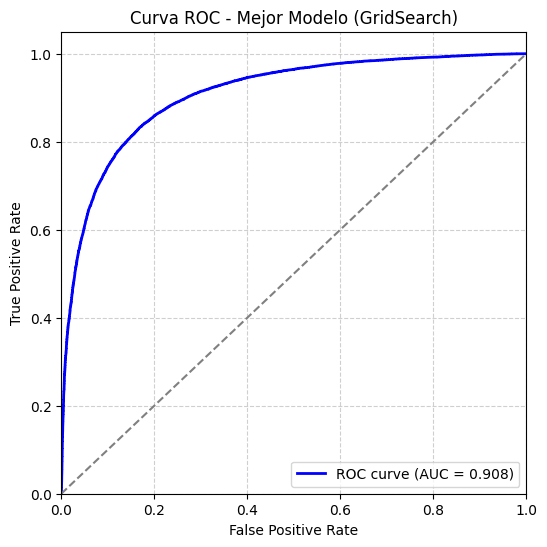


Tabla de importancia de variables:
                feature      coef  importance_abs
44        fuel_electric -4.638968        4.638968
46          fuel_hybrid -3.747556        3.747556
40   manufacturer_tesla  3.085721        3.085721
55       condition_fair -2.967355        2.967355
45             fuel_gas -2.900400        2.900400
..                  ...       ...             ...
59        condition_new  0.032914        0.032914
106            state_wi  0.026166        0.026166
43   manufacturer_volvo -0.022146        0.022146
2                   lat -0.015446        0.015446
57   condition_like new  0.001360        0.001360

[109 rows x 3 columns]


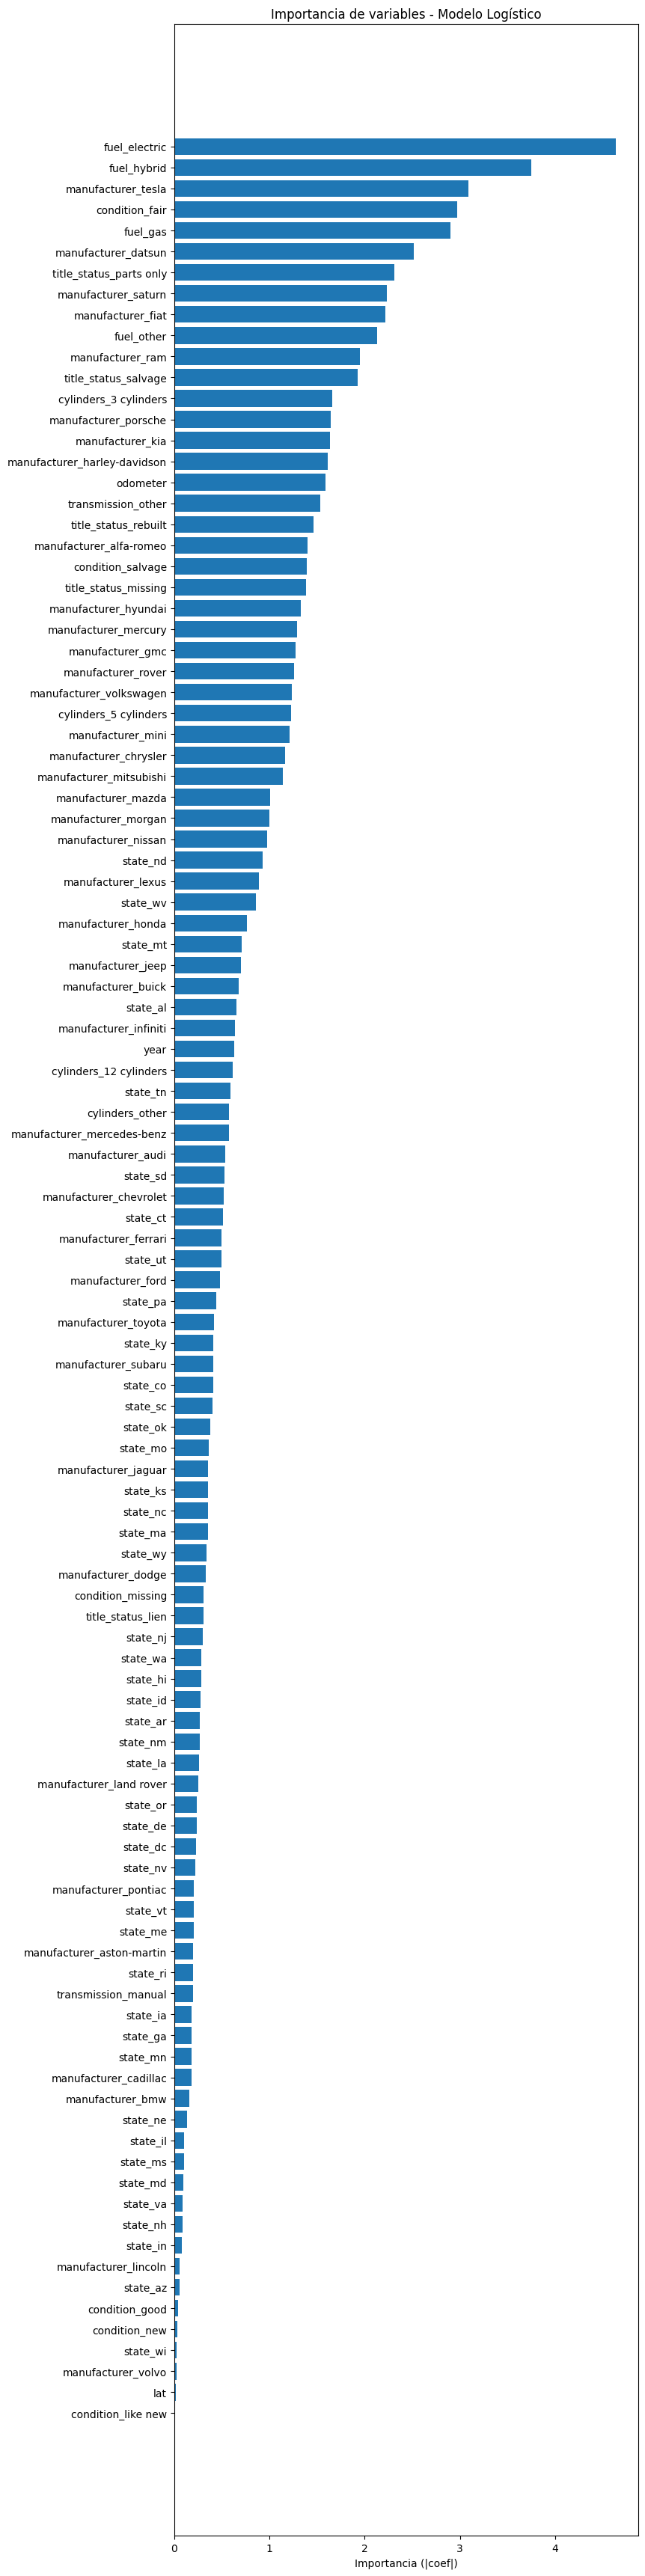

In [134]:
best_model = grid_search.best_estimator_
importances = analizar_modelo_clasificacion(best_model, X_train_clas_final, X_test_clas_final, y_test_clas)

In [135]:
Reporte_clasificacion(best_model, X_test_clas_final, y_test_clas)

Accuracy: 0.8311552466070837
Precision: 0.8312576263533012
Recall: 0.8311552466070837
F1-score: 0.8311421749845476

Matriz de confusión:
[[31719  6044]
 [ 6708 31054]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.84      0.83     37763
           1       0.84      0.82      0.83     37762

    accuracy                           0.83     75525
   macro avg       0.83      0.83      0.83     75525
weighted avg       0.83      0.83      0.83     75525

